# Trustworthy recidivism forecasting

**Client:** a software vendor selling risk-assessment tools to US state community-supervision
agencies. **Task:** pick and justify a three-year re-arrest score to embed in its product, judged on
predictive performance (statistical + economic), interpretability, stability, and fairness — a
trustworthy AI system, not a leaderboard.

Models compared: logistic regression (white-box), XGBoost (ML), TabICLv2 (tabular foundation model).
The outcome is *arrest*, not inherent criminality; this analysis is unsuitable for adverse decisions,
and the score is scoped to allocating voluntary support only.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'artifacts').exists(): ROOT = ROOT.parent
FIG = ROOT / 'artifacts' / 'figures'
sys.path.insert(0, str(ROOT / 'src'))
from recidivism.data import load_official_split

split = load_official_split(ROOT / 'nij-challenge2021_full_dataset.csv')
A = lambda name: pd.read_csv(ROOT / 'artifacts' / name)
metrics = A('model_metrics.csv')
predictions = A('test_predictions.csv')
print(f'Train: {len(split.X_train):,} | Test: {len(split.X_test):,} | Features: {split.X_train.shape[1]}')
print(f'Base recidivism rate (test): {predictions.actual.mean():.1%}')

Train: 18,028 | Test: 7,807 | Features: 29
Base recidivism rate (test): 57.4%


## Design and leakage control

The official `Training_Sample` flag defines the untouched 18,028 / 7,807 split. Only fields available
at supervision start are eligible; post-release variables are excluded because they accrue after the
scoring moment. Race, gender and Residence PUMA (a race proxy) are excluded from inputs and kept for
audit only. Ordered counts are ordinal-encoded; XGBoost hyperparameters come from a 5-fold CV search
(`scripts/tune_xgboost.py`). Full pipeline in `scripts/train_evaluate.py`.

Set `RUN_TRAINING = True` to rebuild every artifact (TabICLv2 runs on GPU at 16 estimators; a CUDA GPU is recommended).

In [2]:
RUN_TRAINING = False
if RUN_TRAINING:
    import subprocess
    for s in ['train_evaluate','incumbent_benchmark','learning_curve','fairness_audit',
              'interpretability','stability_structural','race_ab_test','tradeoff_matrix']:
        subprocess.run([sys.executable, str(ROOT / f'scripts/{s}.py')], cwd=ROOT, check=True)

## 1. The client's real question: better than the incumbent?

`Supervision_Risk_Score_First` is Georgia's existing 1–10 actuarial tool, already in the data. We
benchmark it against our models and random allocation. (145 test rows miss the score; imputed at the
median.)

In [3]:
pd.merge(A('incumbent_discrimination.csv'), A('incumbent_economics.csv')[['ranker','assumed_net_value']], on='ranker').round(3)

,ranker,roc_auc,average_precision,assumed_net_value
0,random,0.505,0.580,1455000.0
1,incumbent,0.600,0.641,2795000.0
2,logistic,0.729,0.769,5015000.0
3,xgboost,0.733,0.772,5265000.0
4,tabicl,0.733,0.772,5125000.0


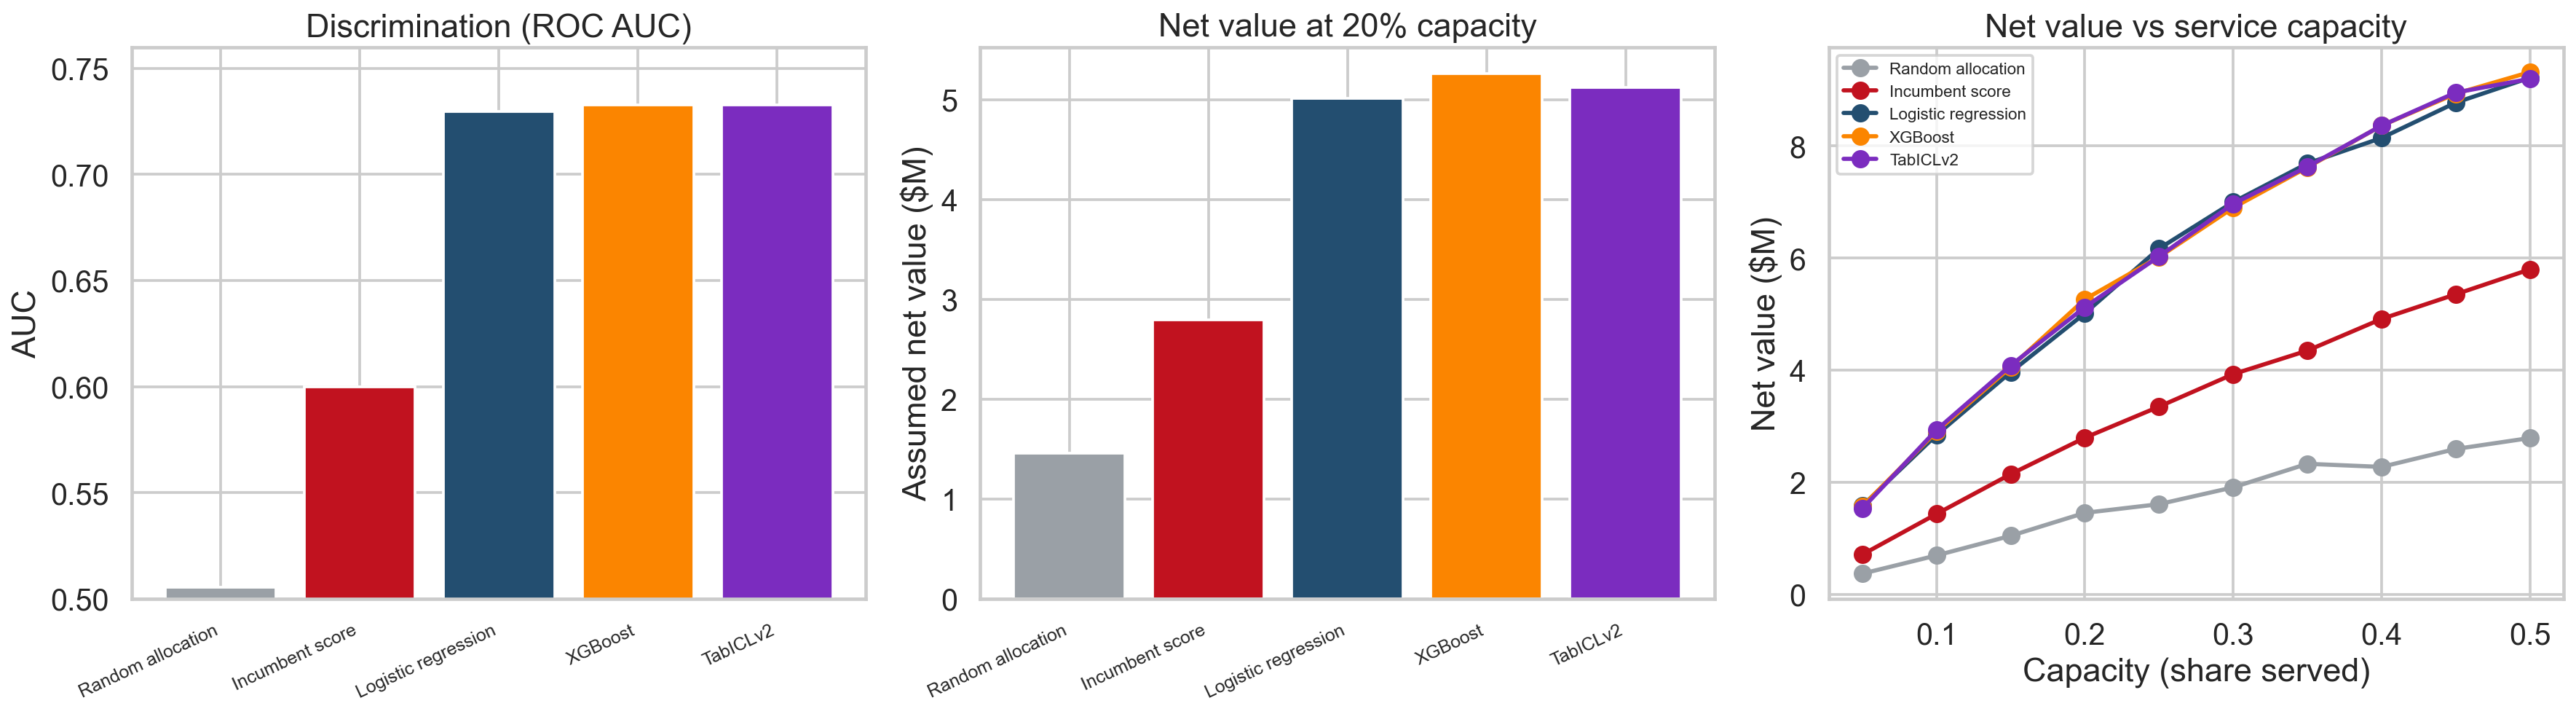

In [4]:
display(Image(filename=str(FIG / 'incumbent_benchmark.png'), width=1100))

The incumbent reaches only ~0.60 AUC; every model reaches ~0.73 and roughly doubles net value. This is the headline for the client — the choice among our three models is secondary.

## 2. Predictive performance (statistical)

In [5]:
metrics[['model','roc_auc','average_precision','brier','log_loss','ece_10','fit_predict_seconds']].round(4).sort_values('brier')

,model,roc_auc,average_precision,brier,log_loss,ece_10,fit_predict_seconds
0,tabicl,0.7328,0.7719,0.2044,0.5945,0.0199,23.1198
1,xgboost,0.7326,0.7722,0.2044,0.5944,0.0109,2.4368
2,logistic,0.7295,0.7691,0.2055,0.5969,0.0132,0.8458


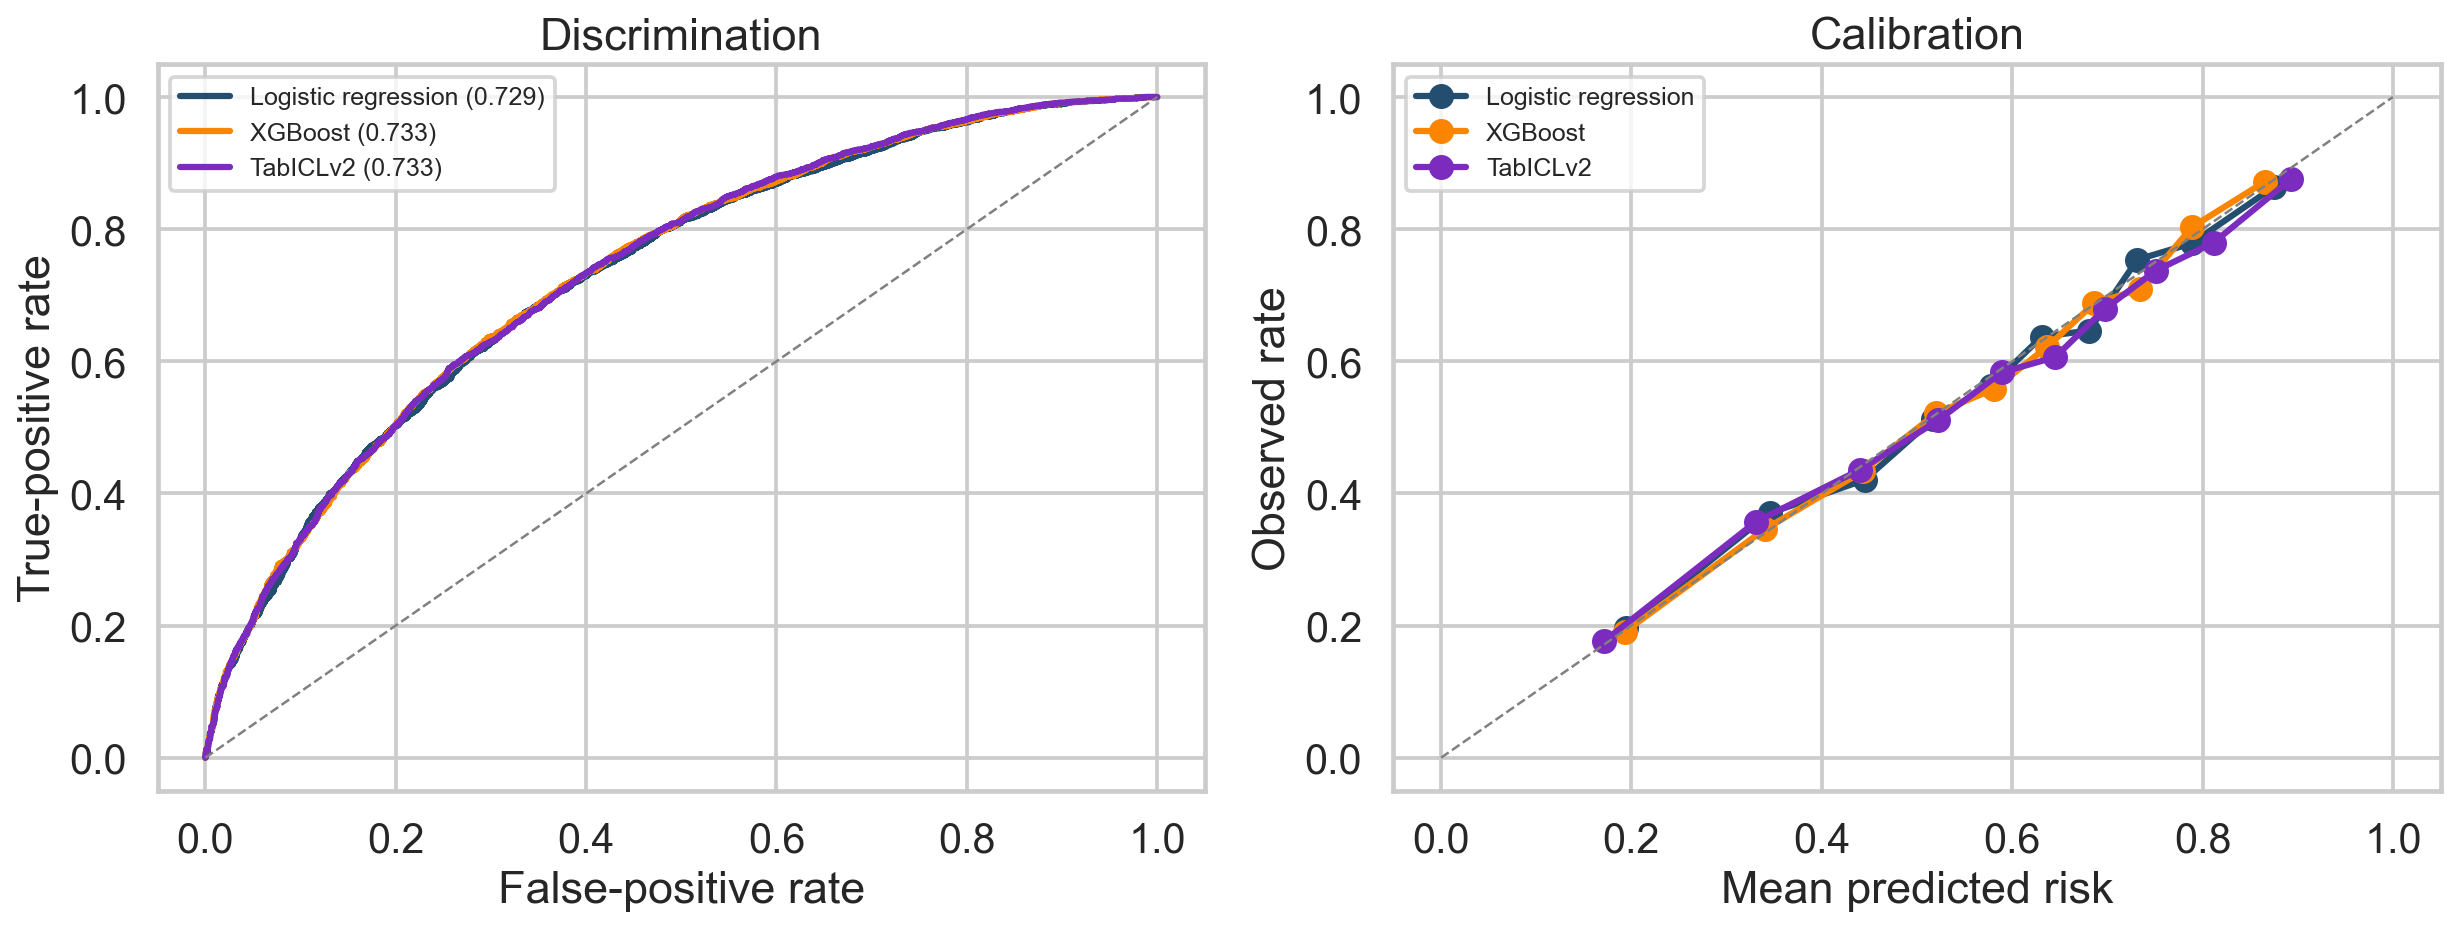

In [6]:
display(Image(filename=str(FIG / 'performance_calibration.png'), width=1000))

In [7]:
intervals = json.loads((ROOT / 'artifacts/bootstrap_intervals.json').read_text())
pd.concat({m: pd.DataFrame(v).T for m, v in intervals.items()}, names=['model','metric']).round(4)

low    high
model    metric                           
logistic roc_auc            0.7177  0.7409
         average_precision  0.7549  0.7831
         brier              0.2016  0.2096
xgboost  roc_auc            0.7205  0.7437
         average_precision  0.7582  0.7862
         brier              0.2005  0.2085
tabicl   roc_auc            0.7208  0.7443
         average_precision  0.7579  0.7860
         brier              0.2001  0.2090

TabICLv2 and XGBoost tie on discrimination and Brier (AUC 0.733 vs 0.733); XGBoost calibrates best (ECE). Bootstrap 95% intervals overlap, so the ranking among the three is not decisive.

### Learning curve: which model for which agency size?

Train sizes 1,500 / 5,000 / 10,000 (3 seeds each) plus the full 18,028 (single seed), all scored on
the fixed test set.

In [8]:
A('learning_curve.csv').groupby(['model','n_train']).roc_auc.agg(['mean','std']).round(4)

mean     std
model    n_train                
logistic 1500     0.7025  0.0040
         5000     0.7202  0.0019
         10000    0.7273  0.0005
         18028    0.7295     NaN
tabicl   1500     0.7196  0.0018
         5000     0.7270  0.0021
         10000    0.7313  0.0015
         18028    0.7328     NaN
xgboost  1500     0.7118  0.0024
         5000     0.7240  0.0026
         10000    0.7306  0.0020
         18028    0.7326     NaN

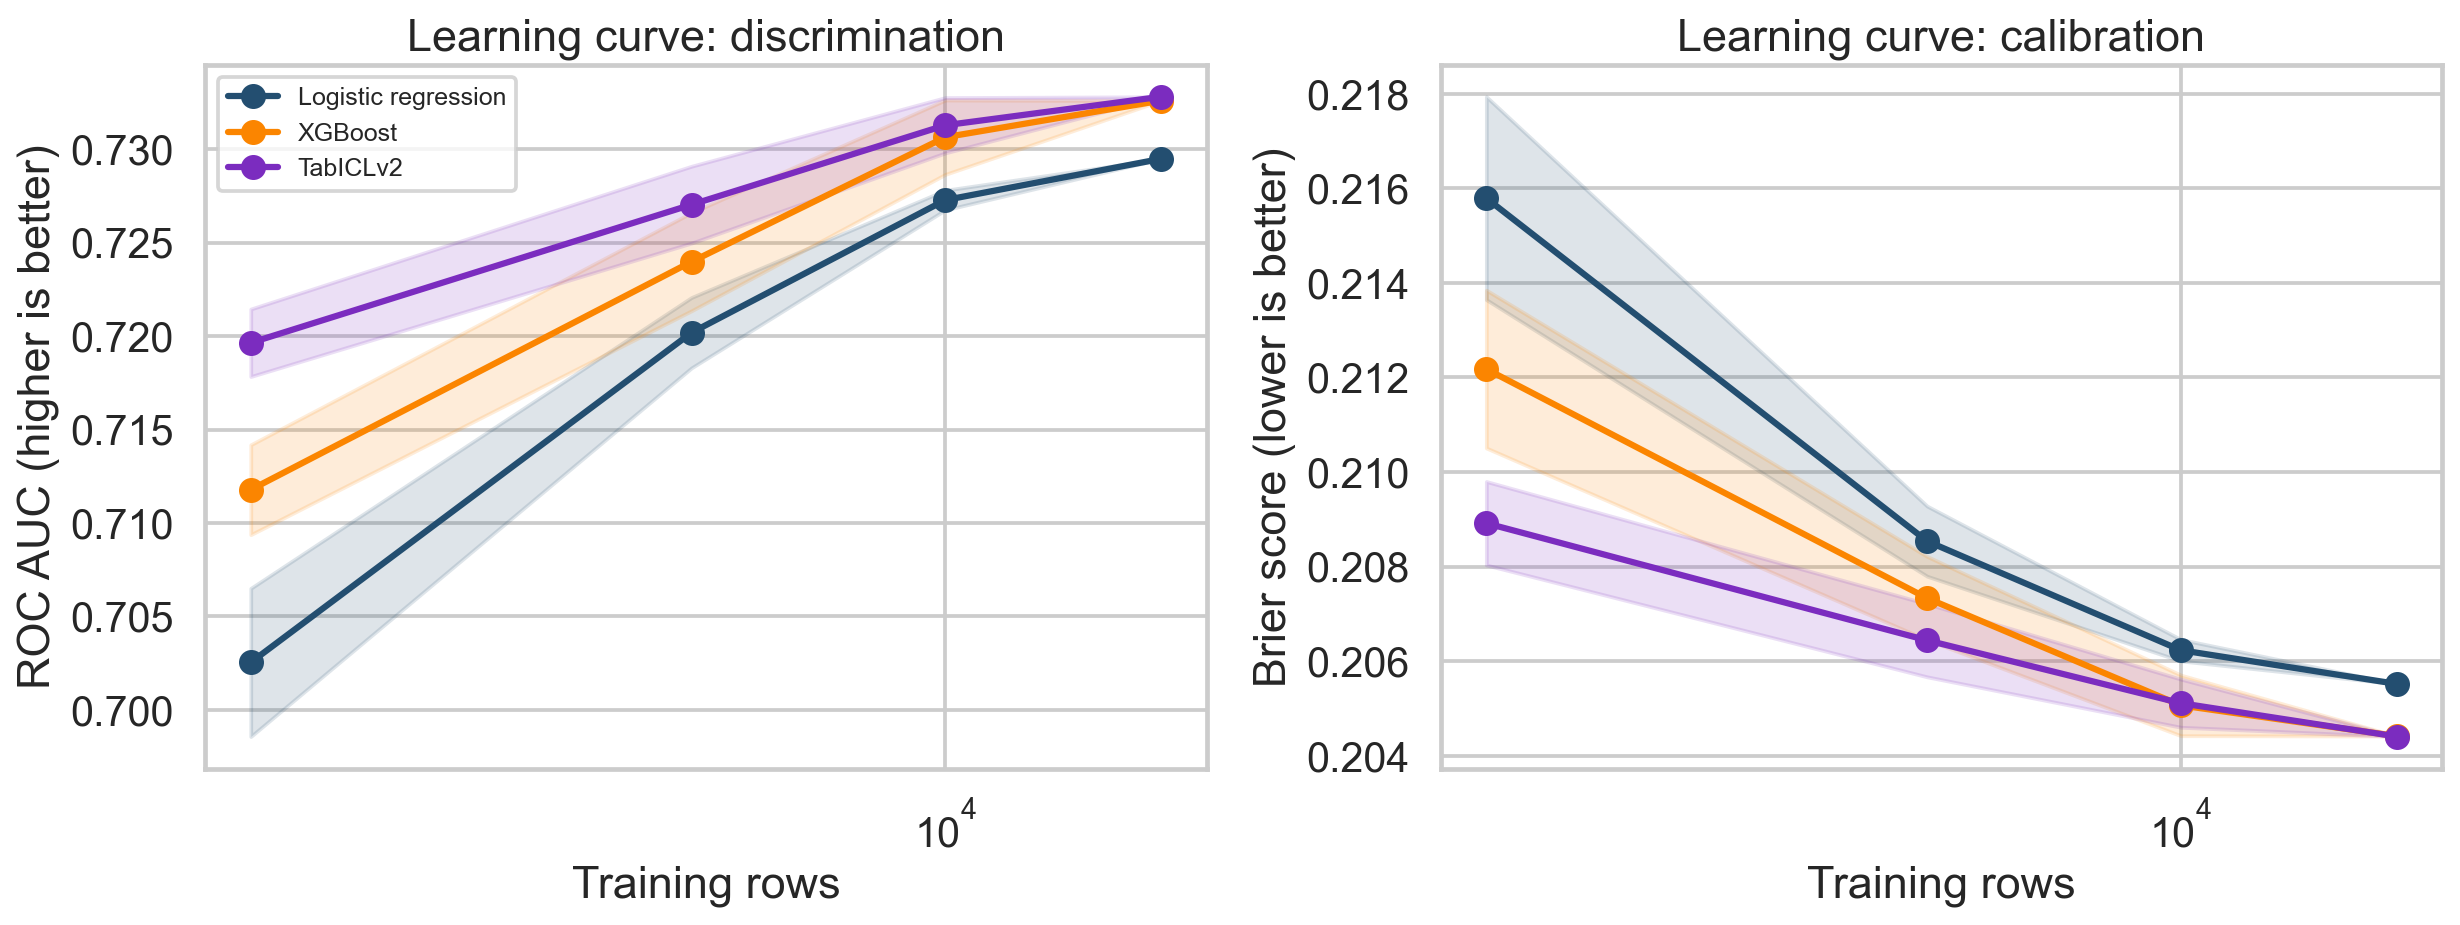

In [9]:
display(Image(filename=str(FIG / 'learning_curve.png'), width=1100))

TabICLv2's few-shot advantage is real on small data (a small county) and shrinks to +0.004 AUC at full data (a large state). No crossover — but at scale the cheaper, explainable model suffices.

## 3. Economic performance

In [10]:
from recidivism.metrics import economic_value
pd.DataFrame([{'model': m, **economic_value(predictions.actual, predictions[f'p_{m}'])}
              for m in ['logistic','xgboost','tabicl']]).round(3)

,model,capacity,selected,captured_events,recall_at_capacity,precision_at_capacity,assumed_gross_benefit,assumed_program_cost,assumed_net_value
0,logistic,0.2,1561,1282,0.286,0.821,12820000.0,7805000.0,5015000.0
1,xgboost,0.2,1561,1307,0.292,0.837,13070000.0,7805000.0,5265000.0
2,tabicl,0.2,1561,1293,0.288,0.828,12930000.0,7805000.0,5125000.0


A transparent scenario ($5k support, $50k event, 20% effectiveness), not a causal estimate. The app exposes a sensitivity sweep; models beat the incumbent at every capacity from 5% to 50%.

## 4. Interpretability (all three models)

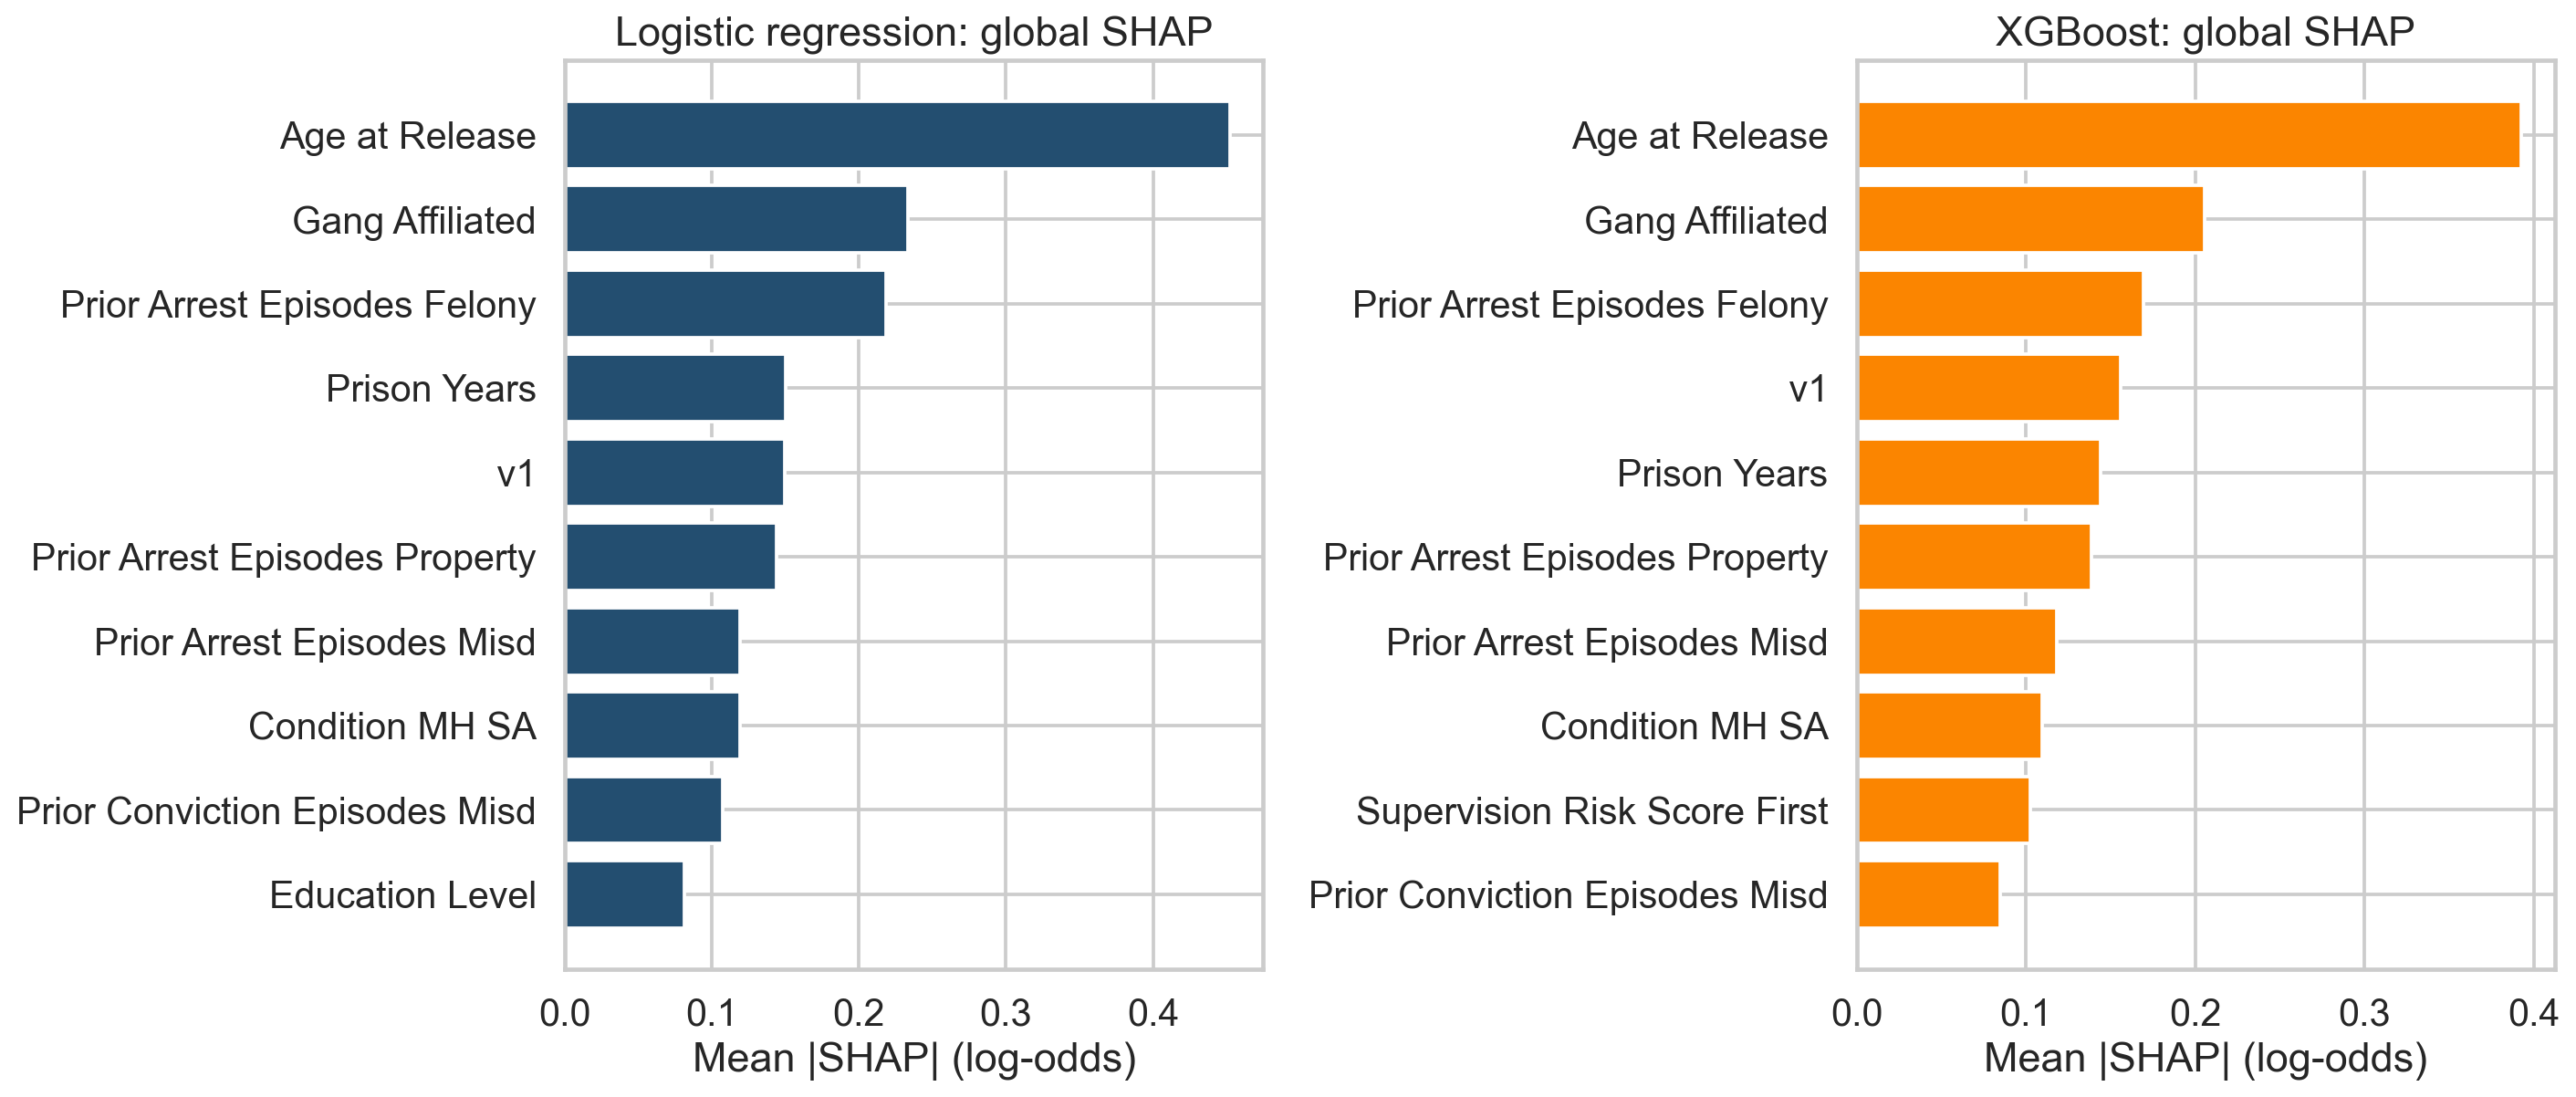

In [11]:
display(Image(filename=str(FIG / 'shap_global.png'), width=1000))

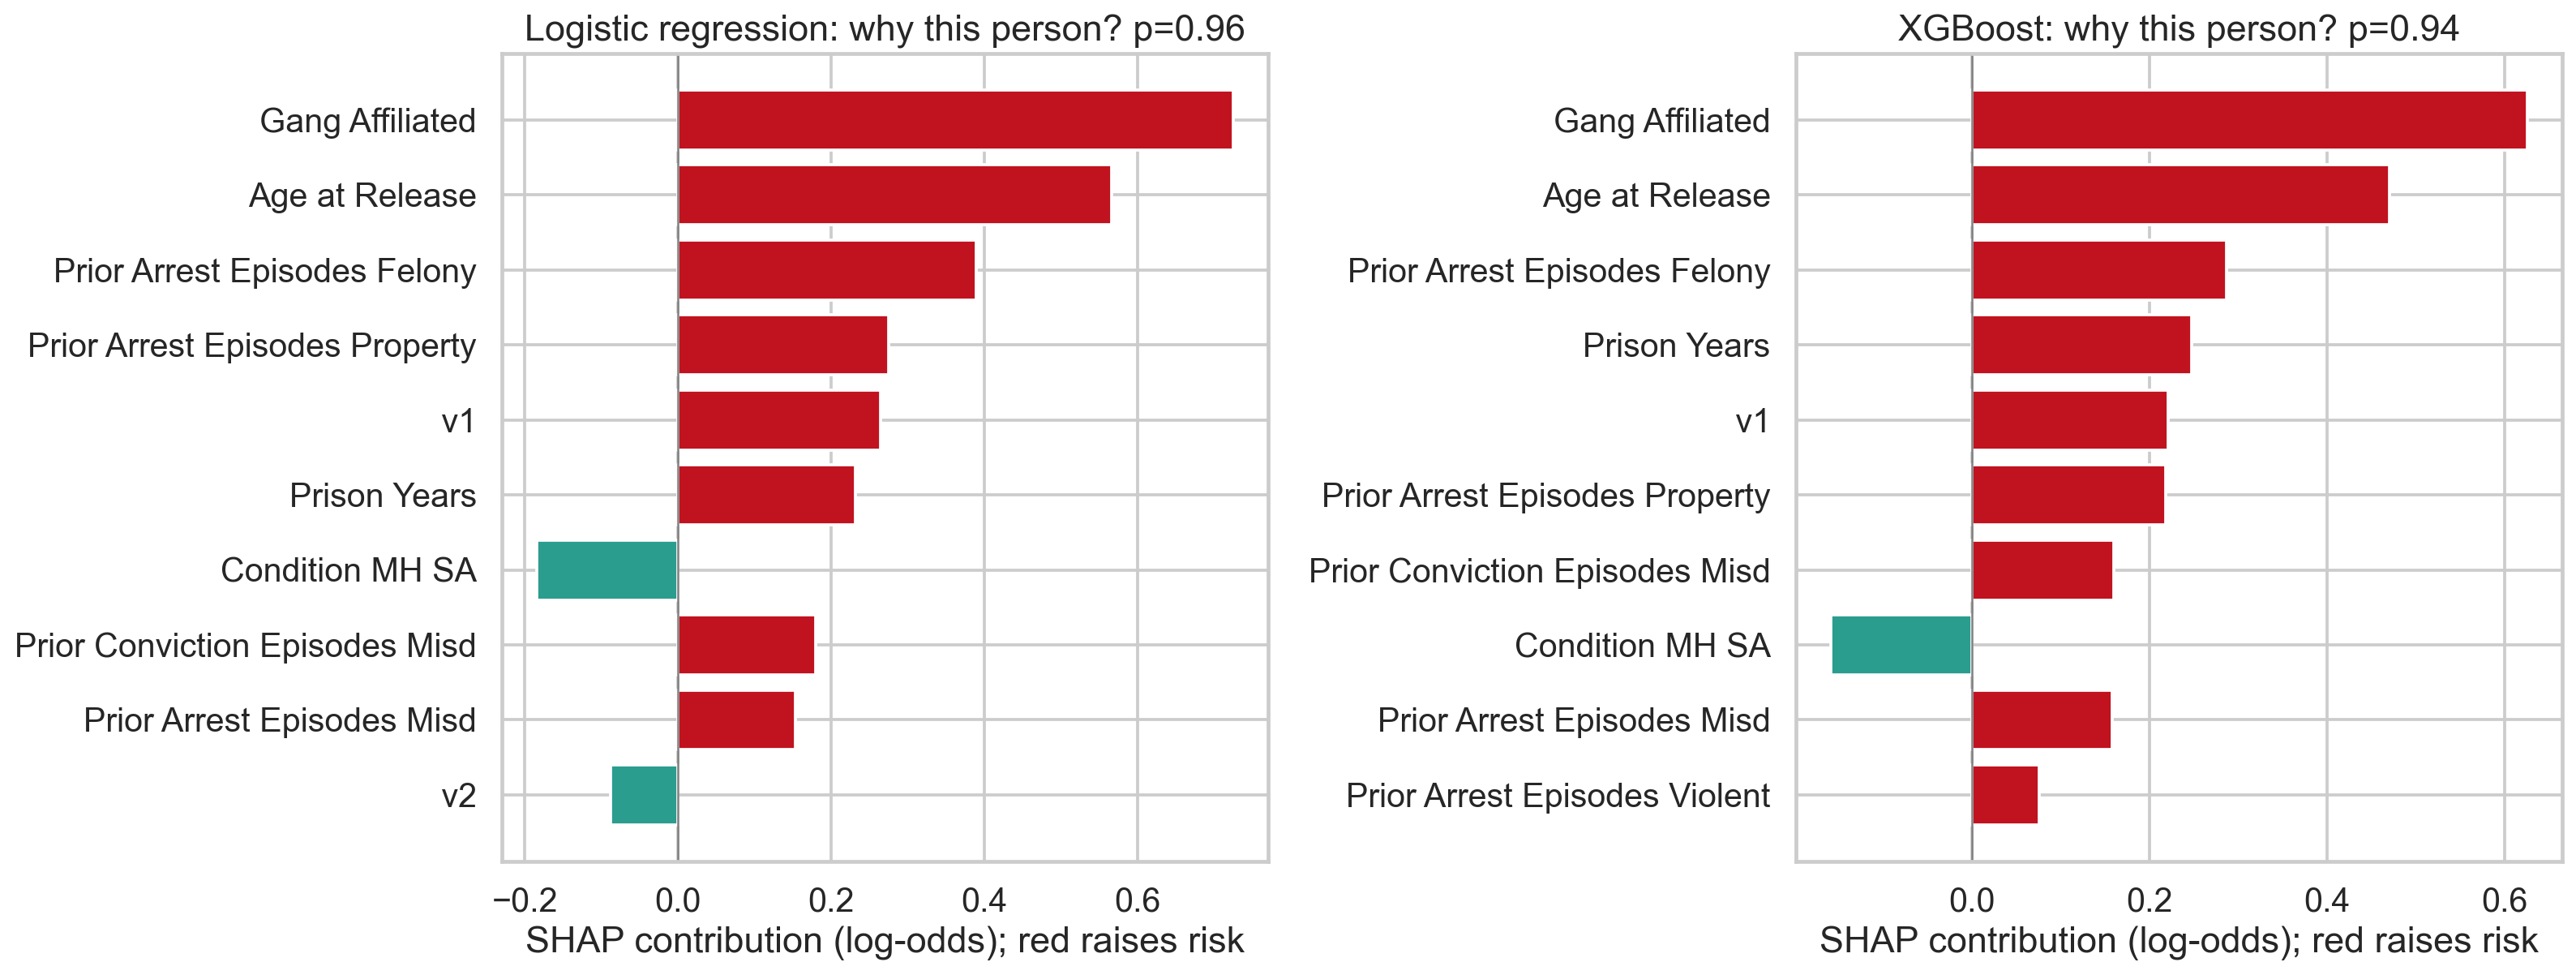

In [12]:
display(Image(filename=str(FIG / 'shap_individual.png'), width=1000))

SHAP: global drivers and an individual waterfall for logistic and XGBoost. Age at release, gang affiliation, prior felony arrests and prison tenure recur. A LIME explanation of the same person (`artifacts/lime_individual.csv`) tells a consistent local story via a different mechanism.

**XPER** (Hué–Hurlin–Pérignon–Saurin) decomposes the model's *AUC* into feature contributions — performance attribution, complementary to SHAP's prediction attribution.

In [13]:
A('xper_values.csv').query("~feature.str.startswith('benchmark')", engine='python').sort_values('xper', ascending=False).groupby('model').head(6).round(4)

,model,feature,xper,sample_auc
1,logistic,Age_at_Release,0.0885,0.7224
31,xgboost,Age_at_Release,0.0844,0.7294
39,xgboost,Prior_Arrest_Episodes_Felony,0.0465,0.7294
9,logistic,Prior_Arrest_Episodes_Felony,0.0418,0.7224
40,xgboost,Prior_Arrest_Episodes_Misd,0.0319,0.7294
44,xgboost,_v1,0.0315,0.7294
14,logistic,_v1,0.0305,0.7224
10,logistic,Prior_Arrest_Episodes_Misd,0.0281,0.7224
32,xgboost,Gang_Affiliated,0.0269,0.7294
2,logistic,Gang_Affiliated,0.0246,0.7224


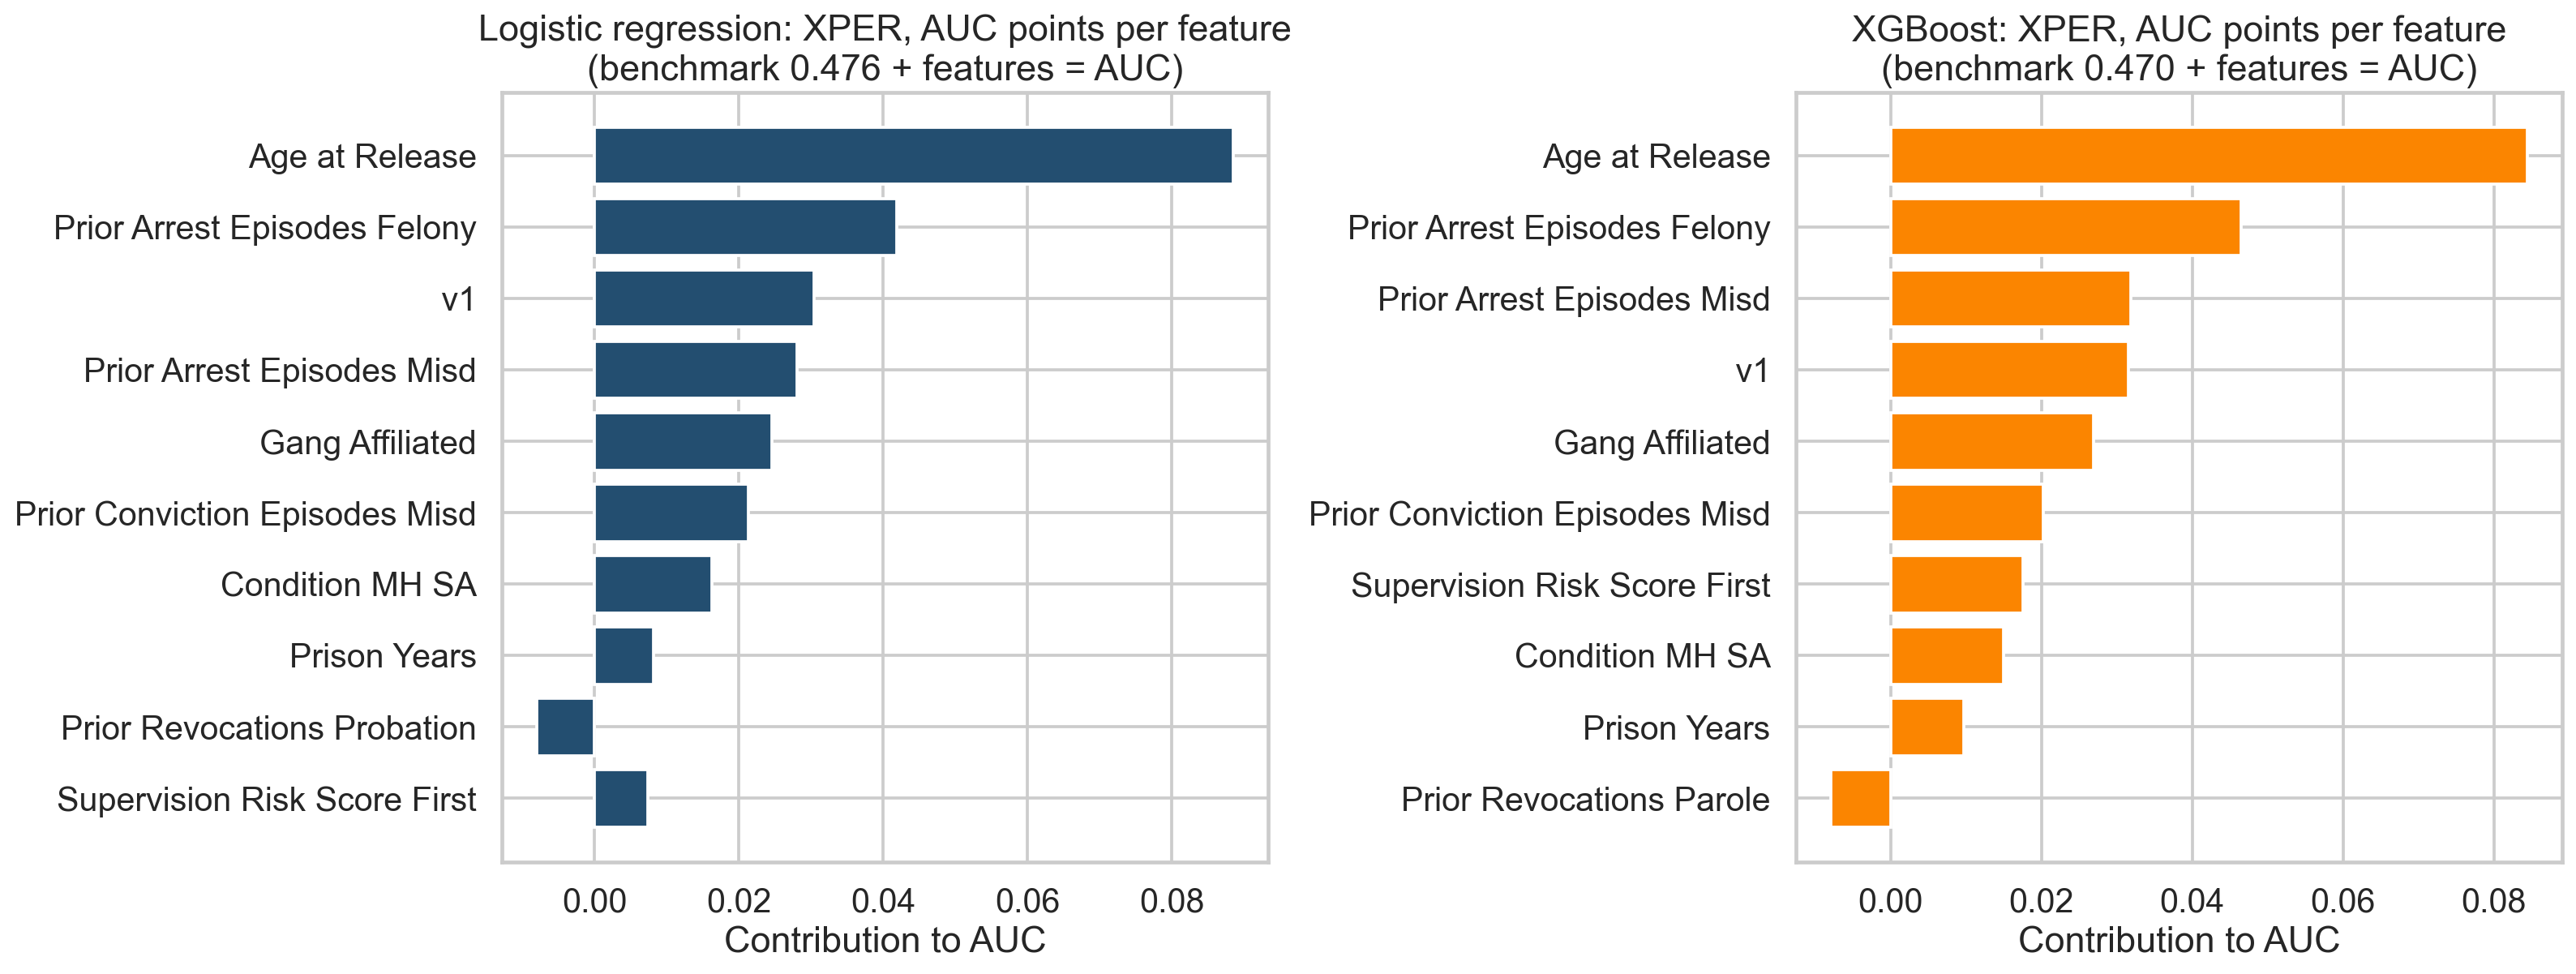

In [14]:
display(Image(filename=str(FIG / 'xper.png'), width=1100))

**Global surrogate**: a depth-3 tree mimics XGBoost (test fidelity R² below) — enough to narrate the logic, not to replace the model. **PDP/ICE** cover all three models, including TabICLv2, which has no native attribution path (a deployment cost, stated openly).

In [15]:
json.loads((ROOT / 'artifacts/interpretability_summary.json').read_text())

{'logistic_individual_probability': 0.9564731225907951,
 'xgboost_individual_probability': 0.9354186654090881,
 'surrogate_depth': 3,
 'surrogate_fidelity_r2_test': 0.6084799808740456,
 'lime': 'ok (features shown in scaled, preprocessed space)',
 'tabicl_native_attribution': 'none: explained only through model-agnostic PDP/ICE and permutation importance'}

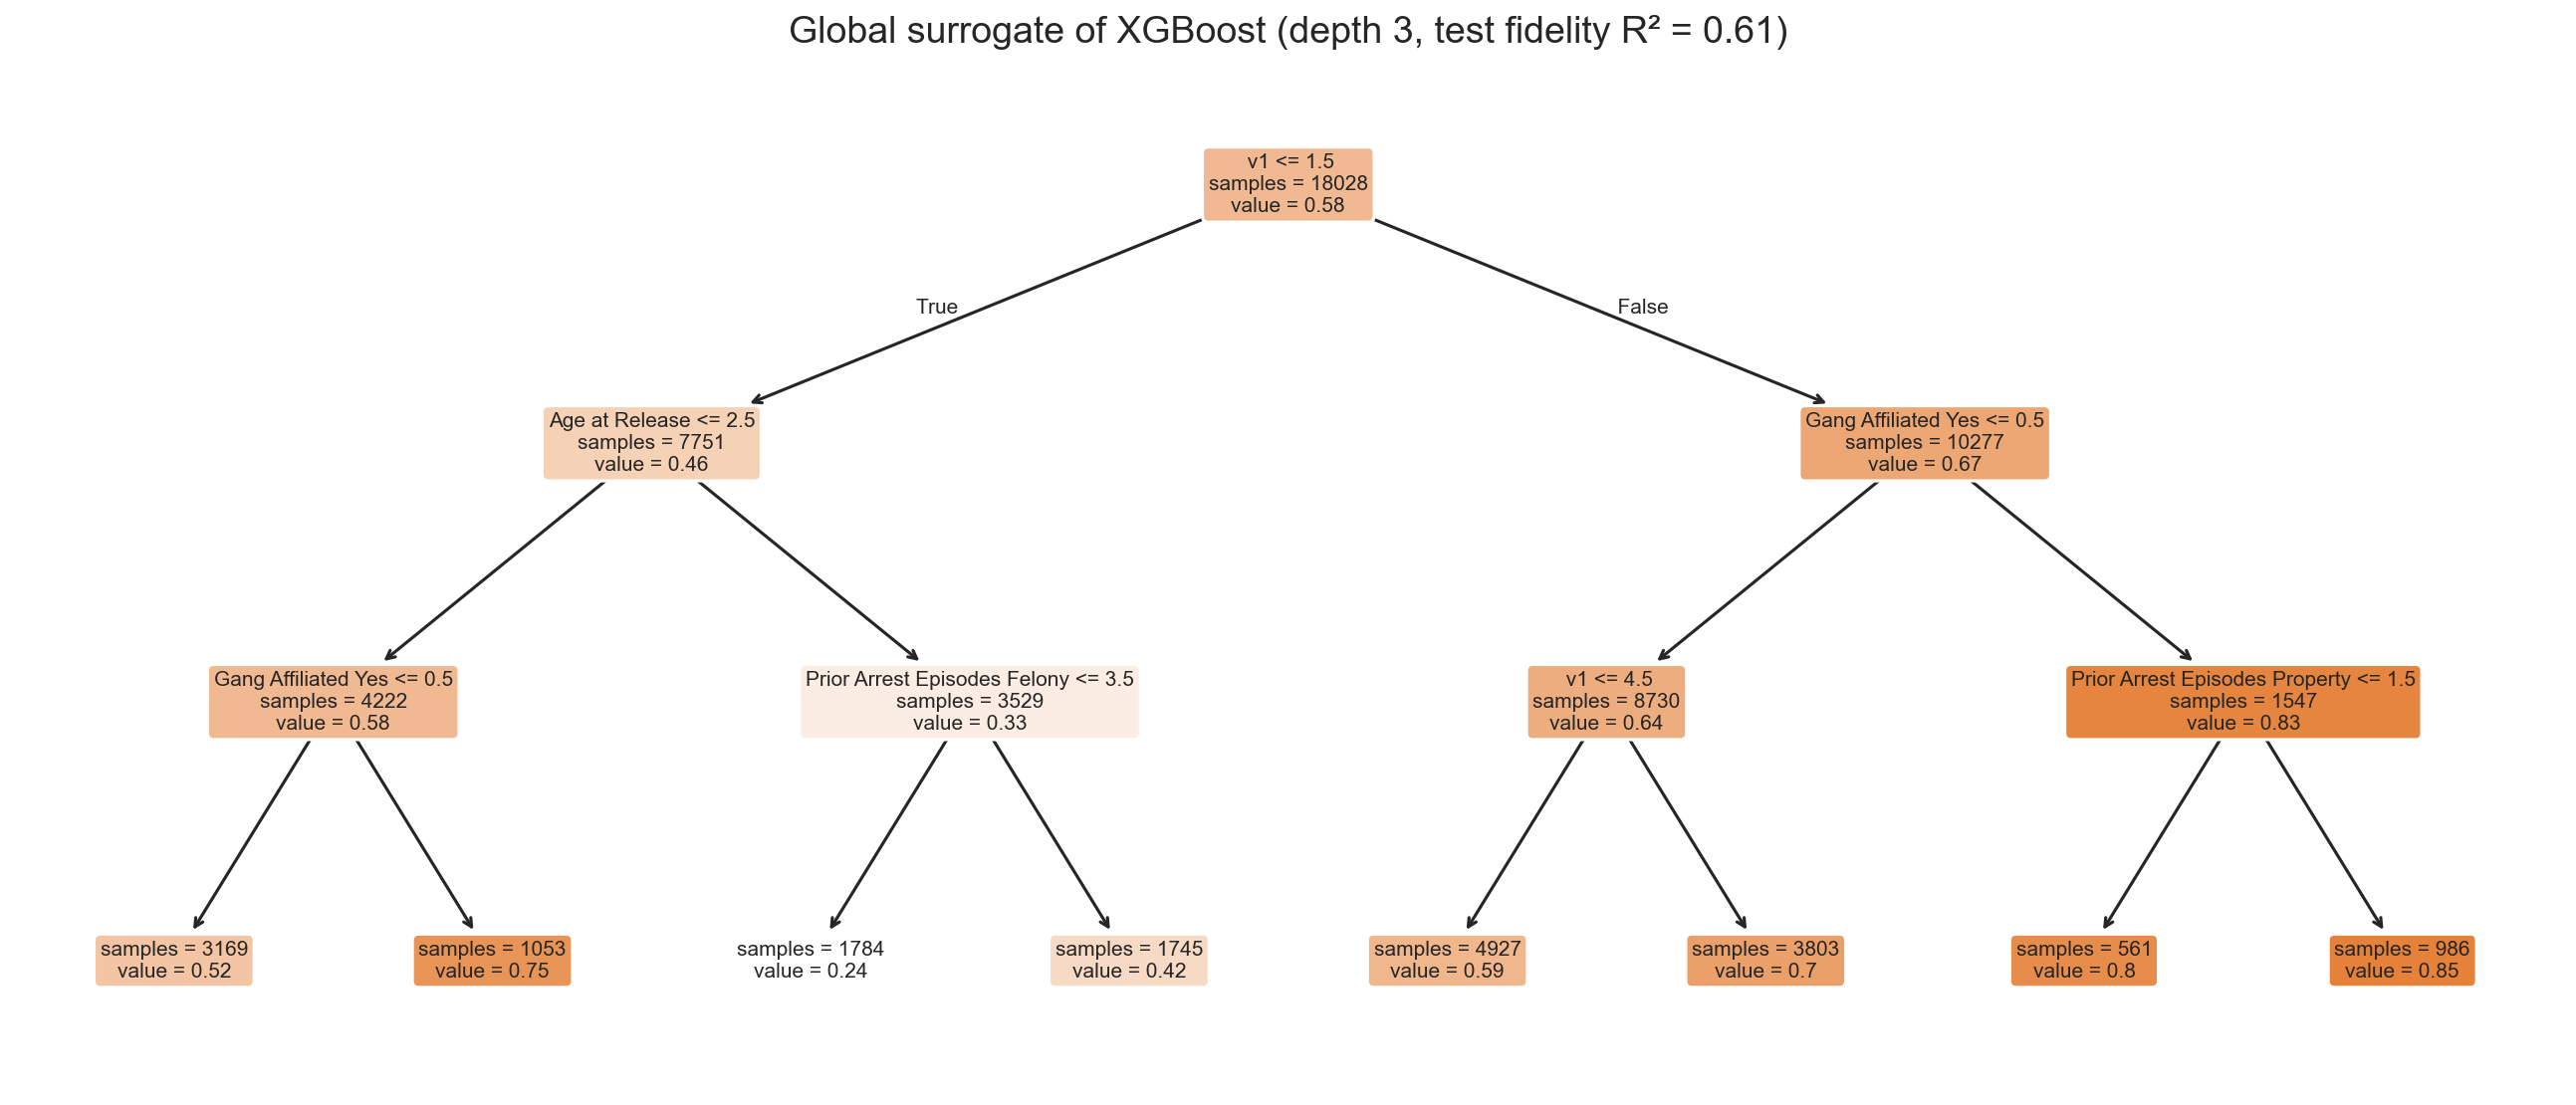

In [16]:
display(Image(filename=str(FIG / 'global_surrogate.png'), width=1100))

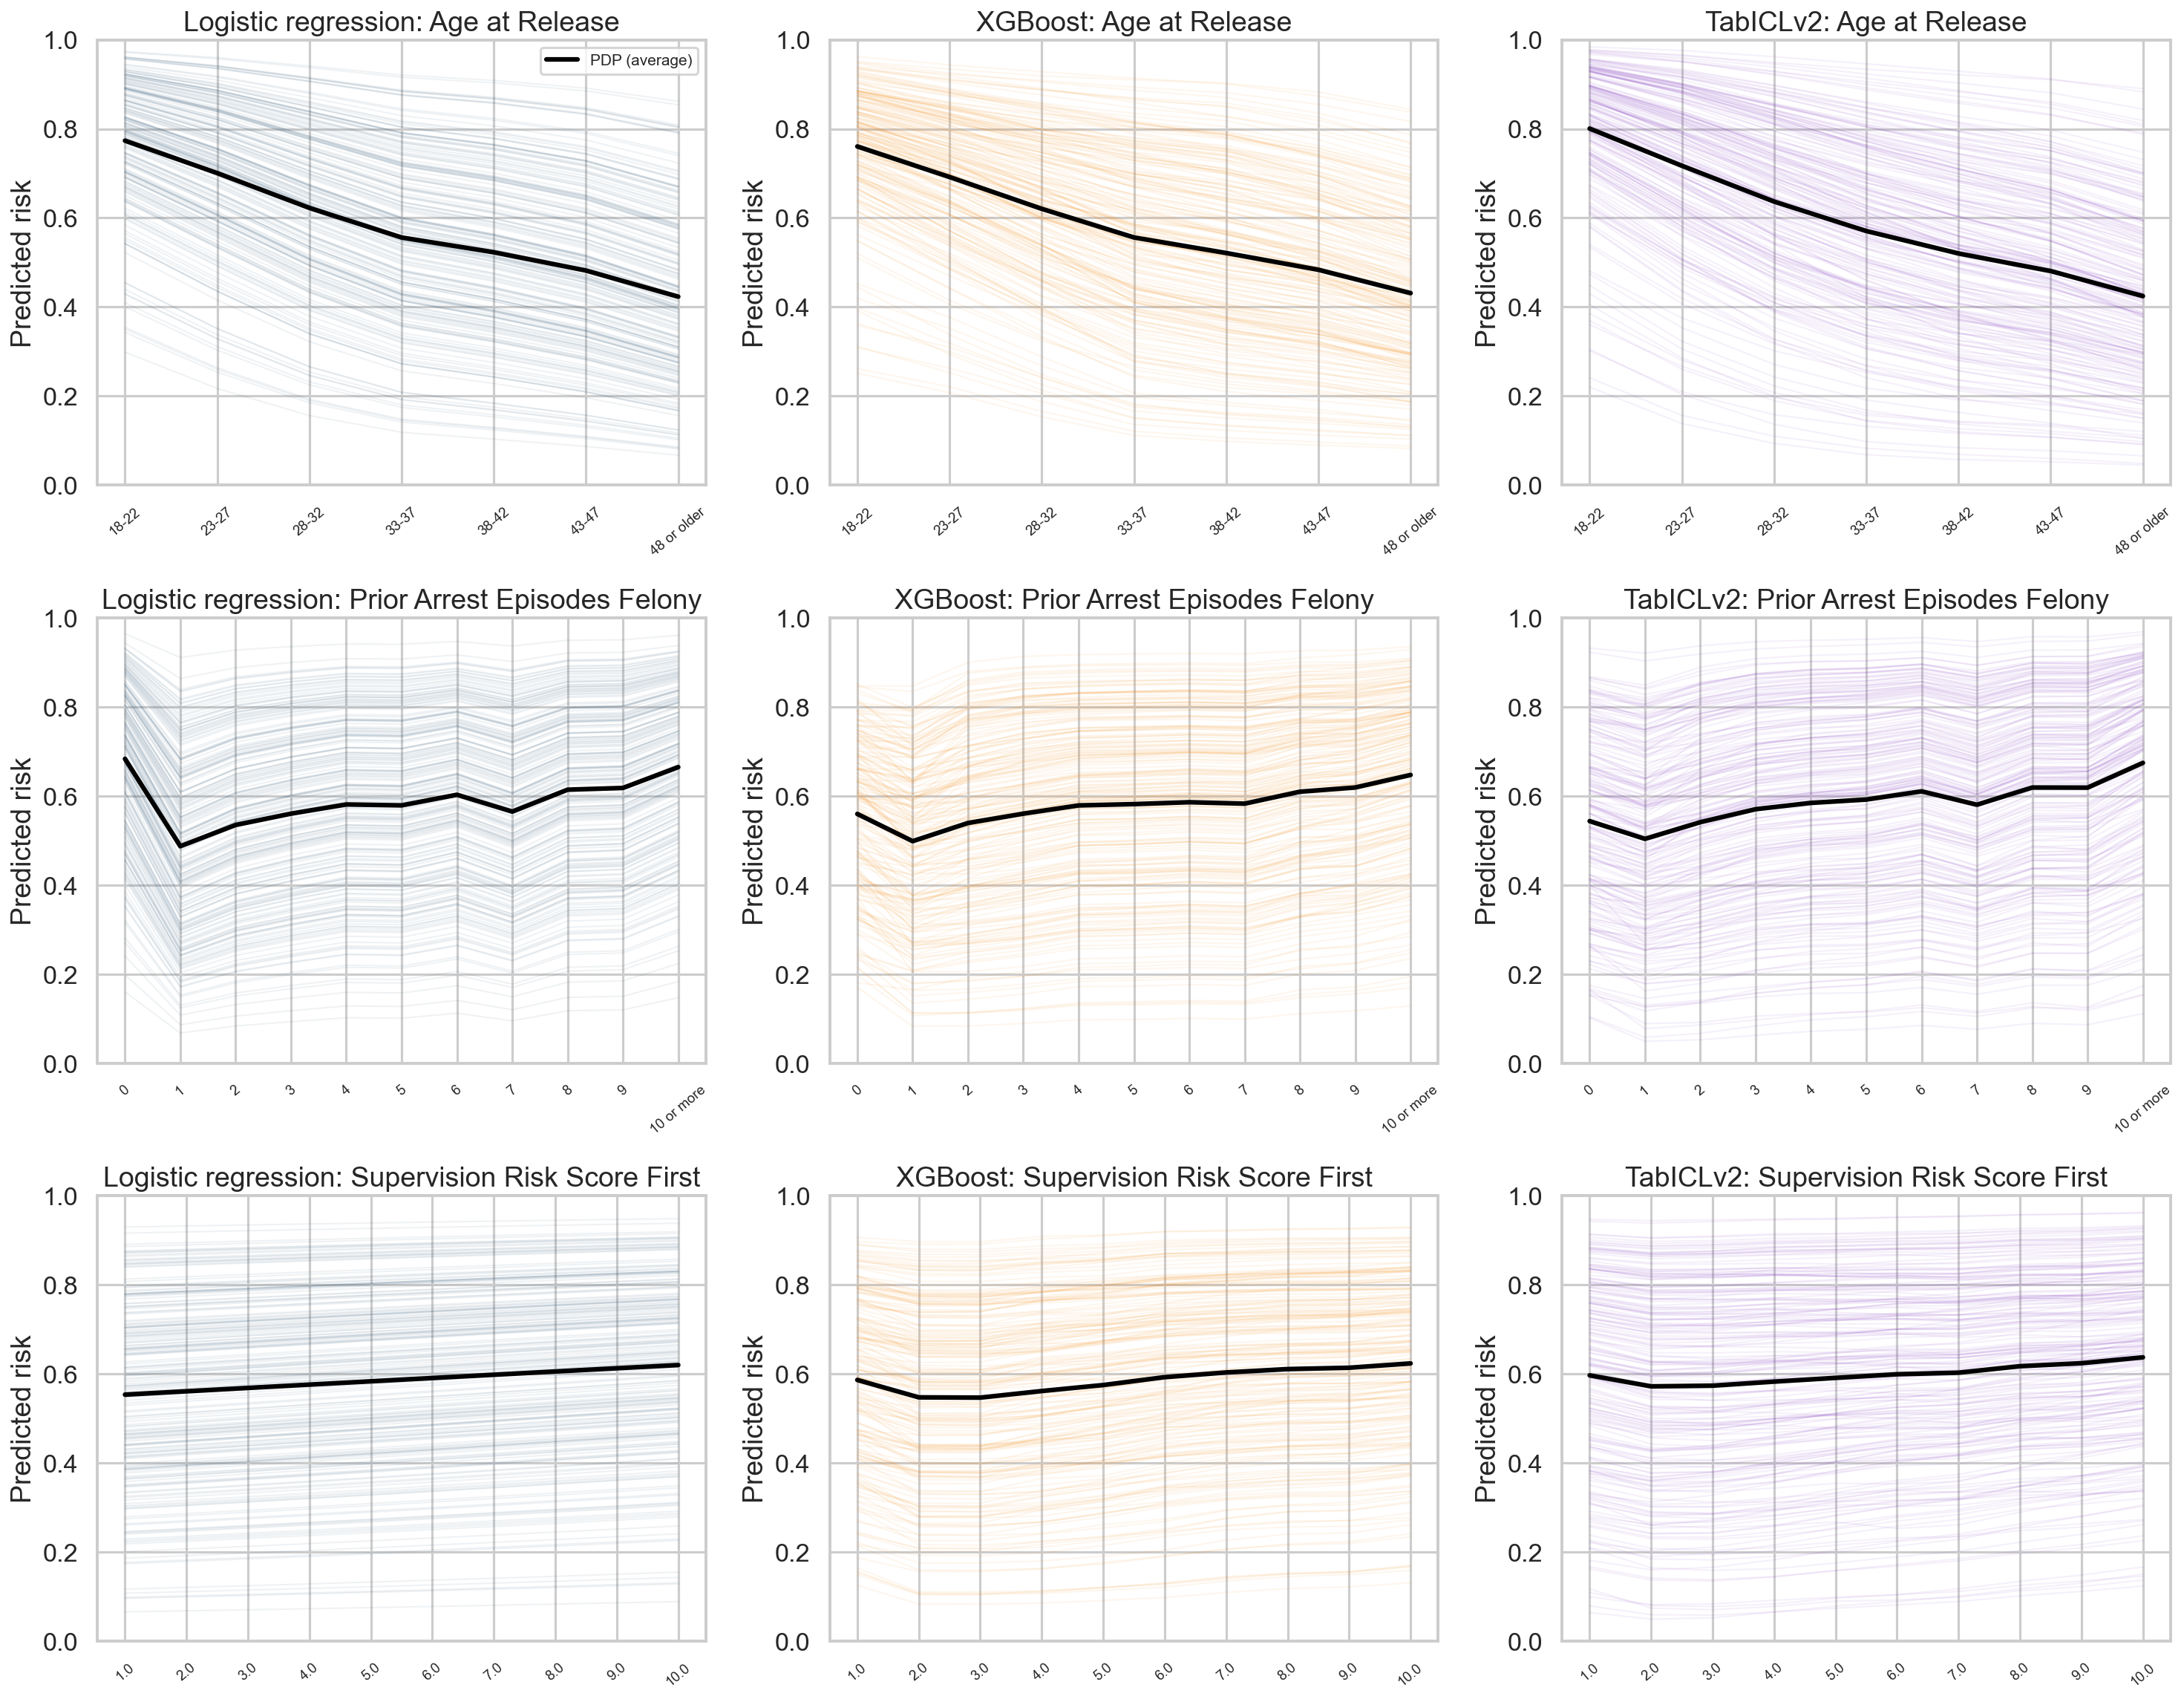

In [17]:
display(Image(filename=str(FIG / 'pdp_ice.png'), width=1100))

## 5. Stability (structural)

In [18]:
A('stability_summary.csv').round(4)

,model,mean_abs_prob_diff,p95_abs_prob_diff,rank_correlation,top20_jaccard,refits
0,logistic,0.0336,0.0877,0.9735,0.7675,8
1,tabicl,0.0362,0.0932,0.9711,0.7694,8
2,xgboost,0.0346,0.0901,0.9713,0.7555,8


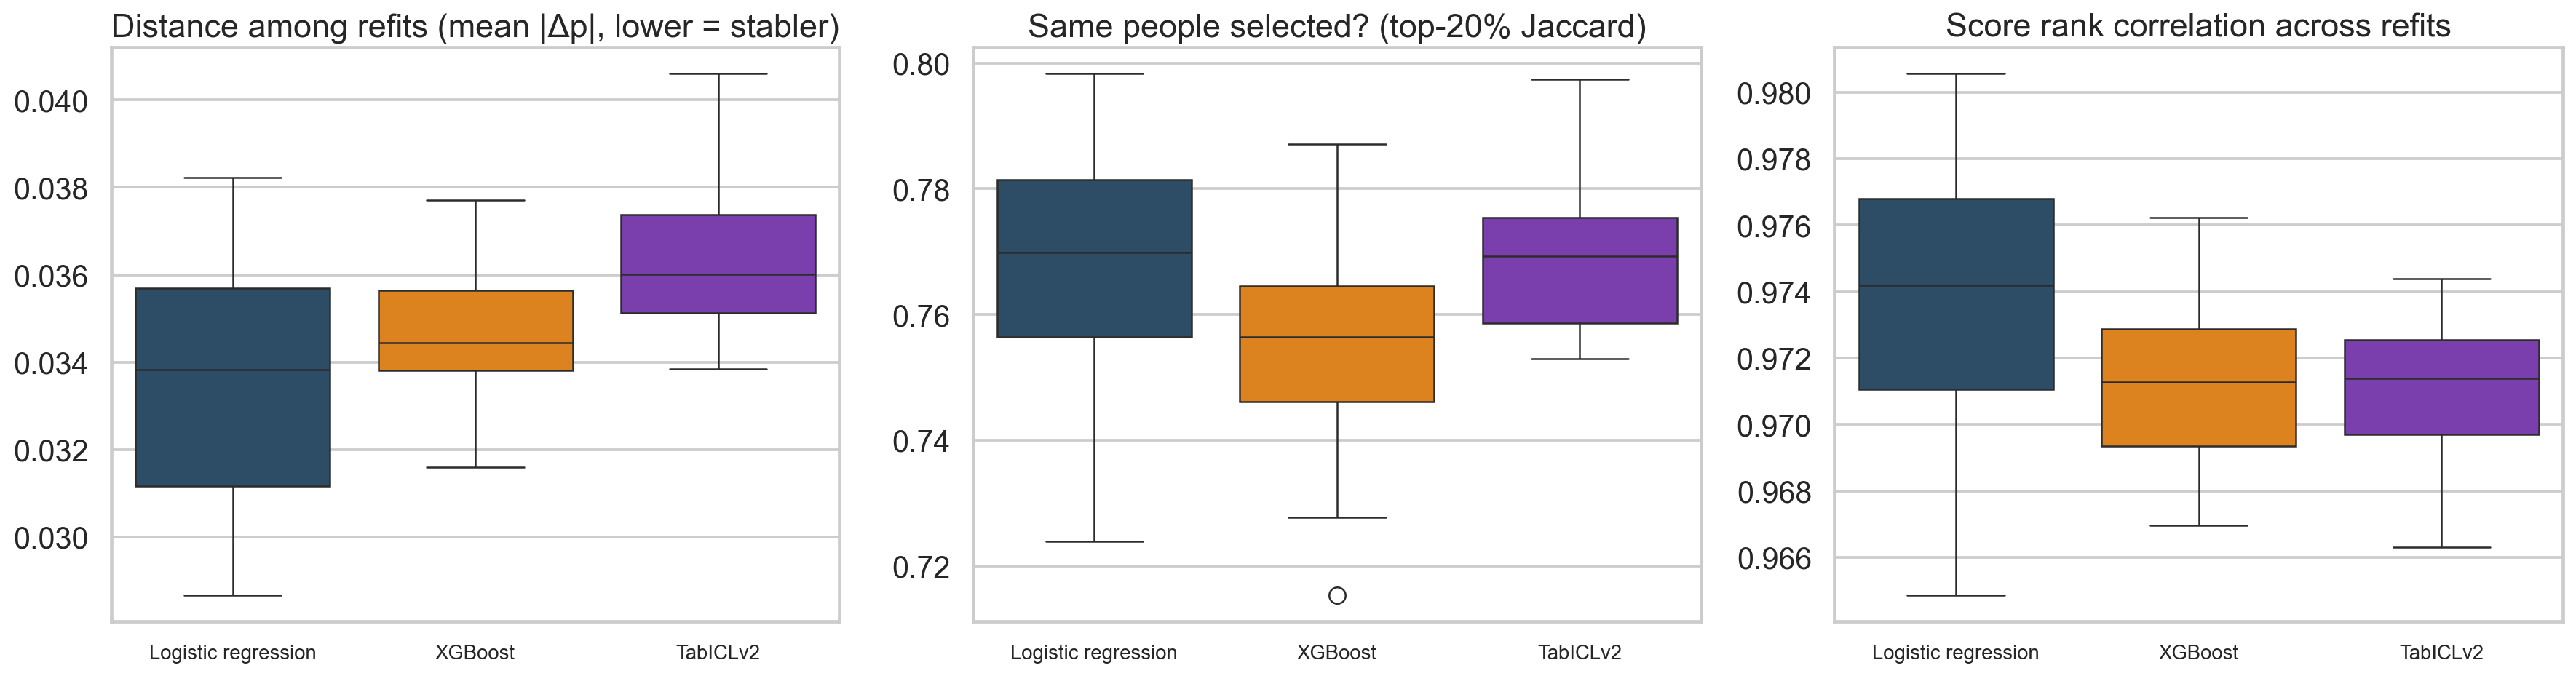

In [19]:
display(Image(filename=str(FIG / 'structural_stability.png'), width=1100))

Each model refit on 8 bootstrap resamples of the training data. All three are comparably stable (drift ~0.034-0.036, decision overlap ~76-77%). About one person in four changes priority status across refits, so scores need governance. Event dates are unavailable, so temporal stability is a deployment gate on a later cohort.

## 6. Fairness

### Gaps at the deployed operating point, with inference tests
The product allocates the top 20% by risk, so we audit there (and at 0.5) with bootstrap 95% CIs.

In [20]:
inf = A('fairness_inference.csv')
inf[(inf.rule=='top_20pct') & inf.metric.isin(['fpr','tpr','selection_rate'])].round(3).sort_values(['attribute','metric','model'])

,model,attribute,comparison,rule,metric,gap,ci_low,ci_high,significant
17,logistic,Gender,M minus F,top_20pct,fpr,0.040,0.018,0.060,True
57,tabicl,Gender,M minus F,top_20pct,fpr,0.041,0.019,0.061,True
37,xgboost,Gender,M minus F,top_20pct,fpr,0.036,0.017,0.057,True
15,logistic,Gender,M minus F,top_20pct,selection_rate,0.091,0.071,0.116,True
55,tabicl,Gender,M minus F,top_20pct,selection_rate,0.107,0.086,0.128,True
35,xgboost,Gender,M minus F,top_20pct,selection_rate,0.098,0.078,0.122,True
16,logistic,Gender,M minus F,top_20pct,tpr,0.091,0.055,0.135,True
56,tabicl,Gender,M minus F,top_20pct,tpr,0.121,0.081,0.160,True
36,xgboost,Gender,M minus F,top_20pct,tpr,0.107,0.069,0.150,True
7,logistic,Race,BLACK minus WHITE,top_20pct,fpr,0.017,-0.003,0.034,False


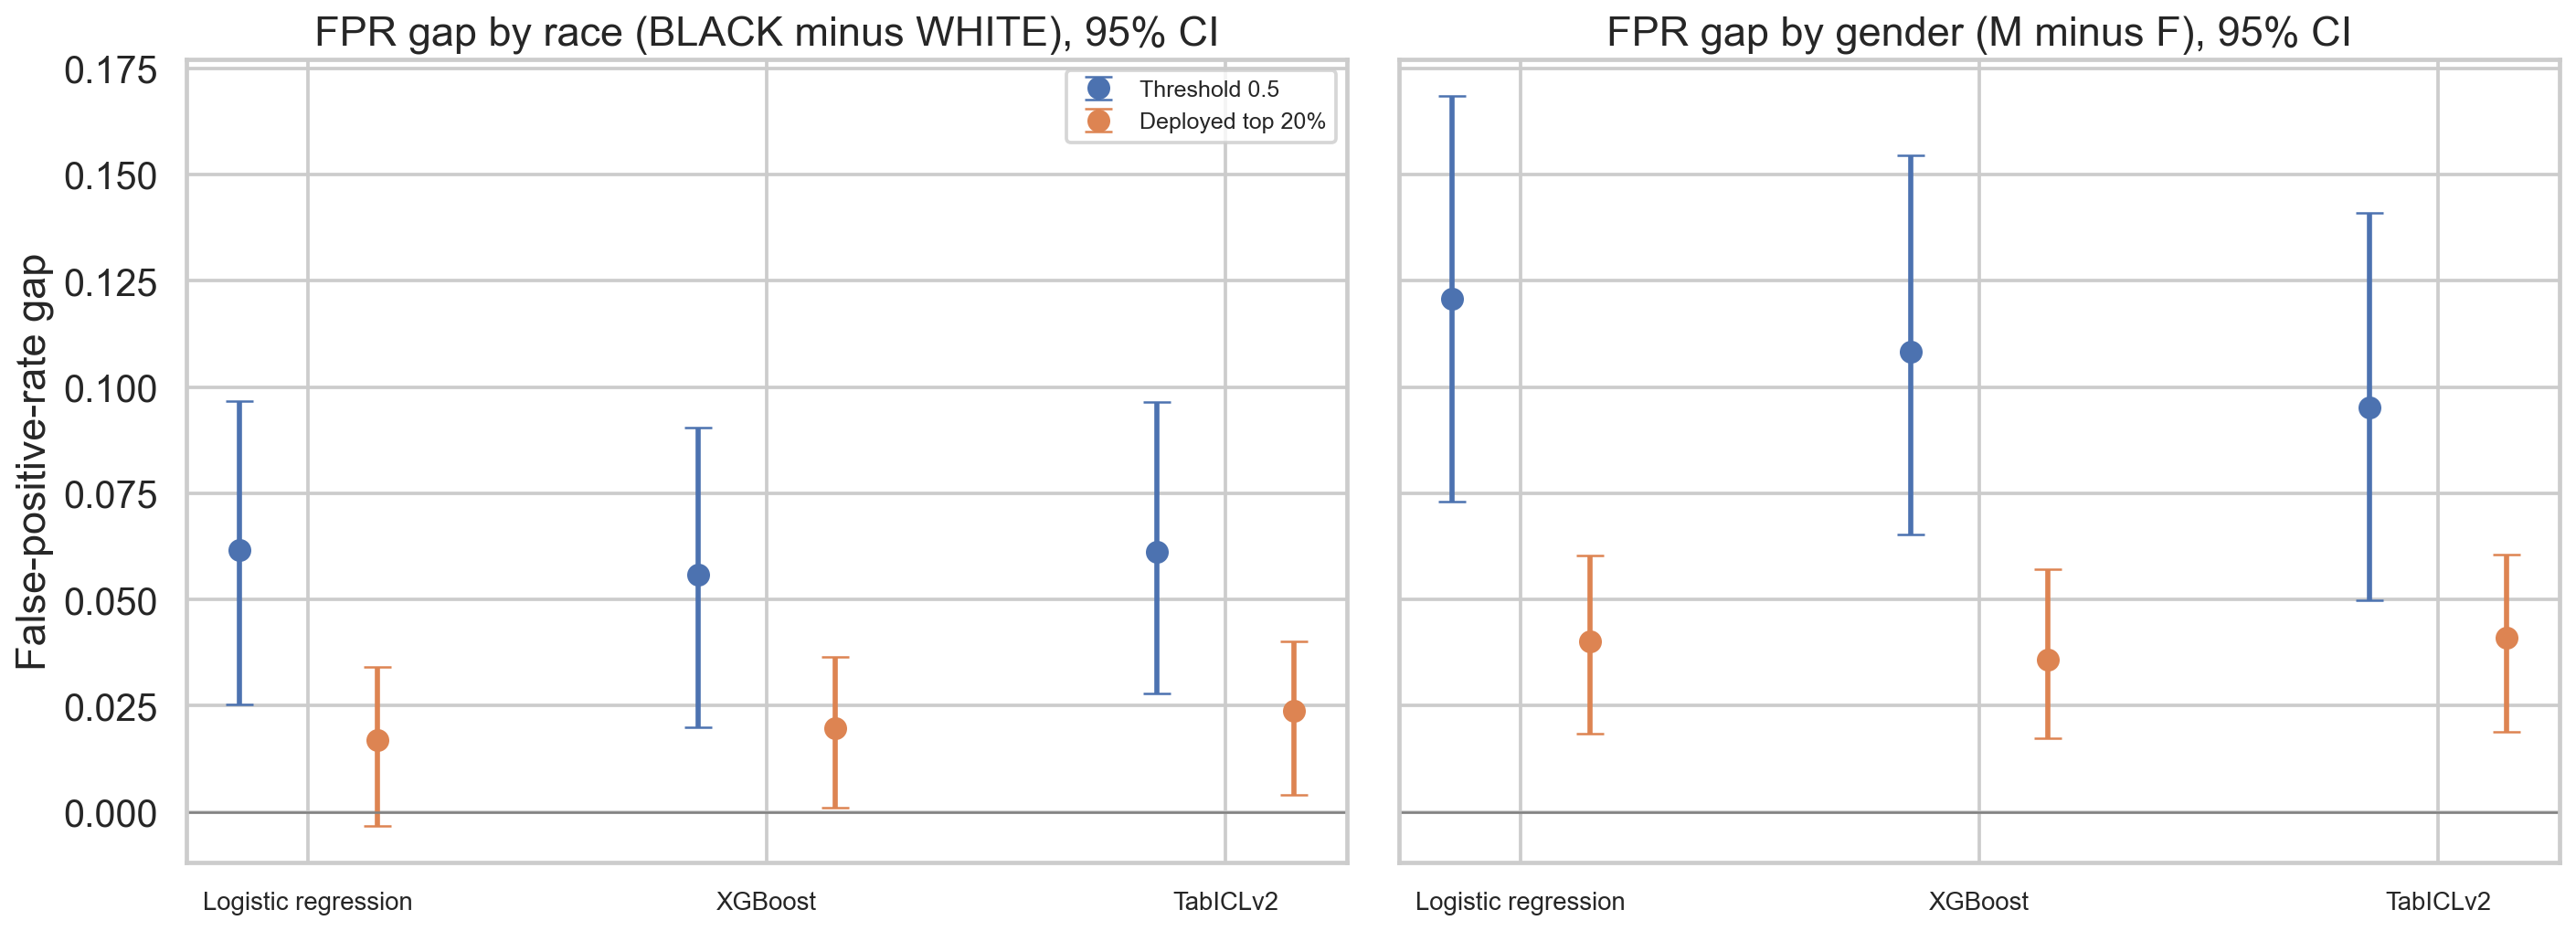

In [21]:
display(Image(filename=str(FIG / 'fairness_operating_point.png'), width=1100))

Auditing at 0.5 would overstate gaps ~2–3× (TabICLv2 gender 0.106 at 0.5 vs 0.041 at top-20%).

### The impossibility result, split by attribute

In [22]:
A('fairness_impossibility.csv').round(3)

,attribute,group,n,base_rate,mean_score_logistic,ece_logistic,mean_score_xgboost,ece_xgboost,mean_score_tabicl,ece_tabicl
0,Race,BLACK,4534,0.582,0.587,0.017,0.587,0.012,0.594,0.024
1,Race,WHITE,3273,0.564,0.567,0.016,0.567,0.014,0.572,0.018
2,Gender,M,6857,0.591,0.587,0.012,0.587,0.010,0.594,0.022
3,Gender,F,950,0.454,0.521,0.077,0.523,0.069,0.523,0.073


Race base rates barely differ (0.582 vs 0.564) → calibration and equal error rates are
near-jointly achievable, so the race FPR gap is a *model property*. Gender base rates differ by 13.7
points (0.591 vs 0.454) → the theorem binds; because race is excluded, logistic/XGBoost over-predict
women. This explains why gender gaps exceed race gaps.

### Mitigation frontier (race and gender)
Group-specific thresholds trace the fairness/utility frontier. They are an **analytic device**, not a shipping option — a per-race/gender threshold is disparate treatment (Ricci v. DeStefano).

In [23]:
A('fairness_frontier.csv').query("method=='group_thresholds_equal_fpr'").round(4)

,model,attribute,method,capacity,fpr_gap,captured_events,base_rate_gap
10,logistic,Race,group_thresholds_equal_fpr,0.2,0.0004,1283,0.0176
21,xgboost,Race,group_thresholds_equal_fpr,0.2,0.0018,1299,0.0176
32,tabicl,Race,group_thresholds_equal_fpr,0.2,0.0008,1294,0.0176
43,logistic,Gender,group_thresholds_equal_fpr,0.2,0.0002,1285,0.1372
54,xgboost,Gender,group_thresholds_equal_fpr,0.2,-0.0001,1305,0.1372
65,tabicl,Gender,group_thresholds_equal_fpr,0.2,-0.0018,1297,0.1372


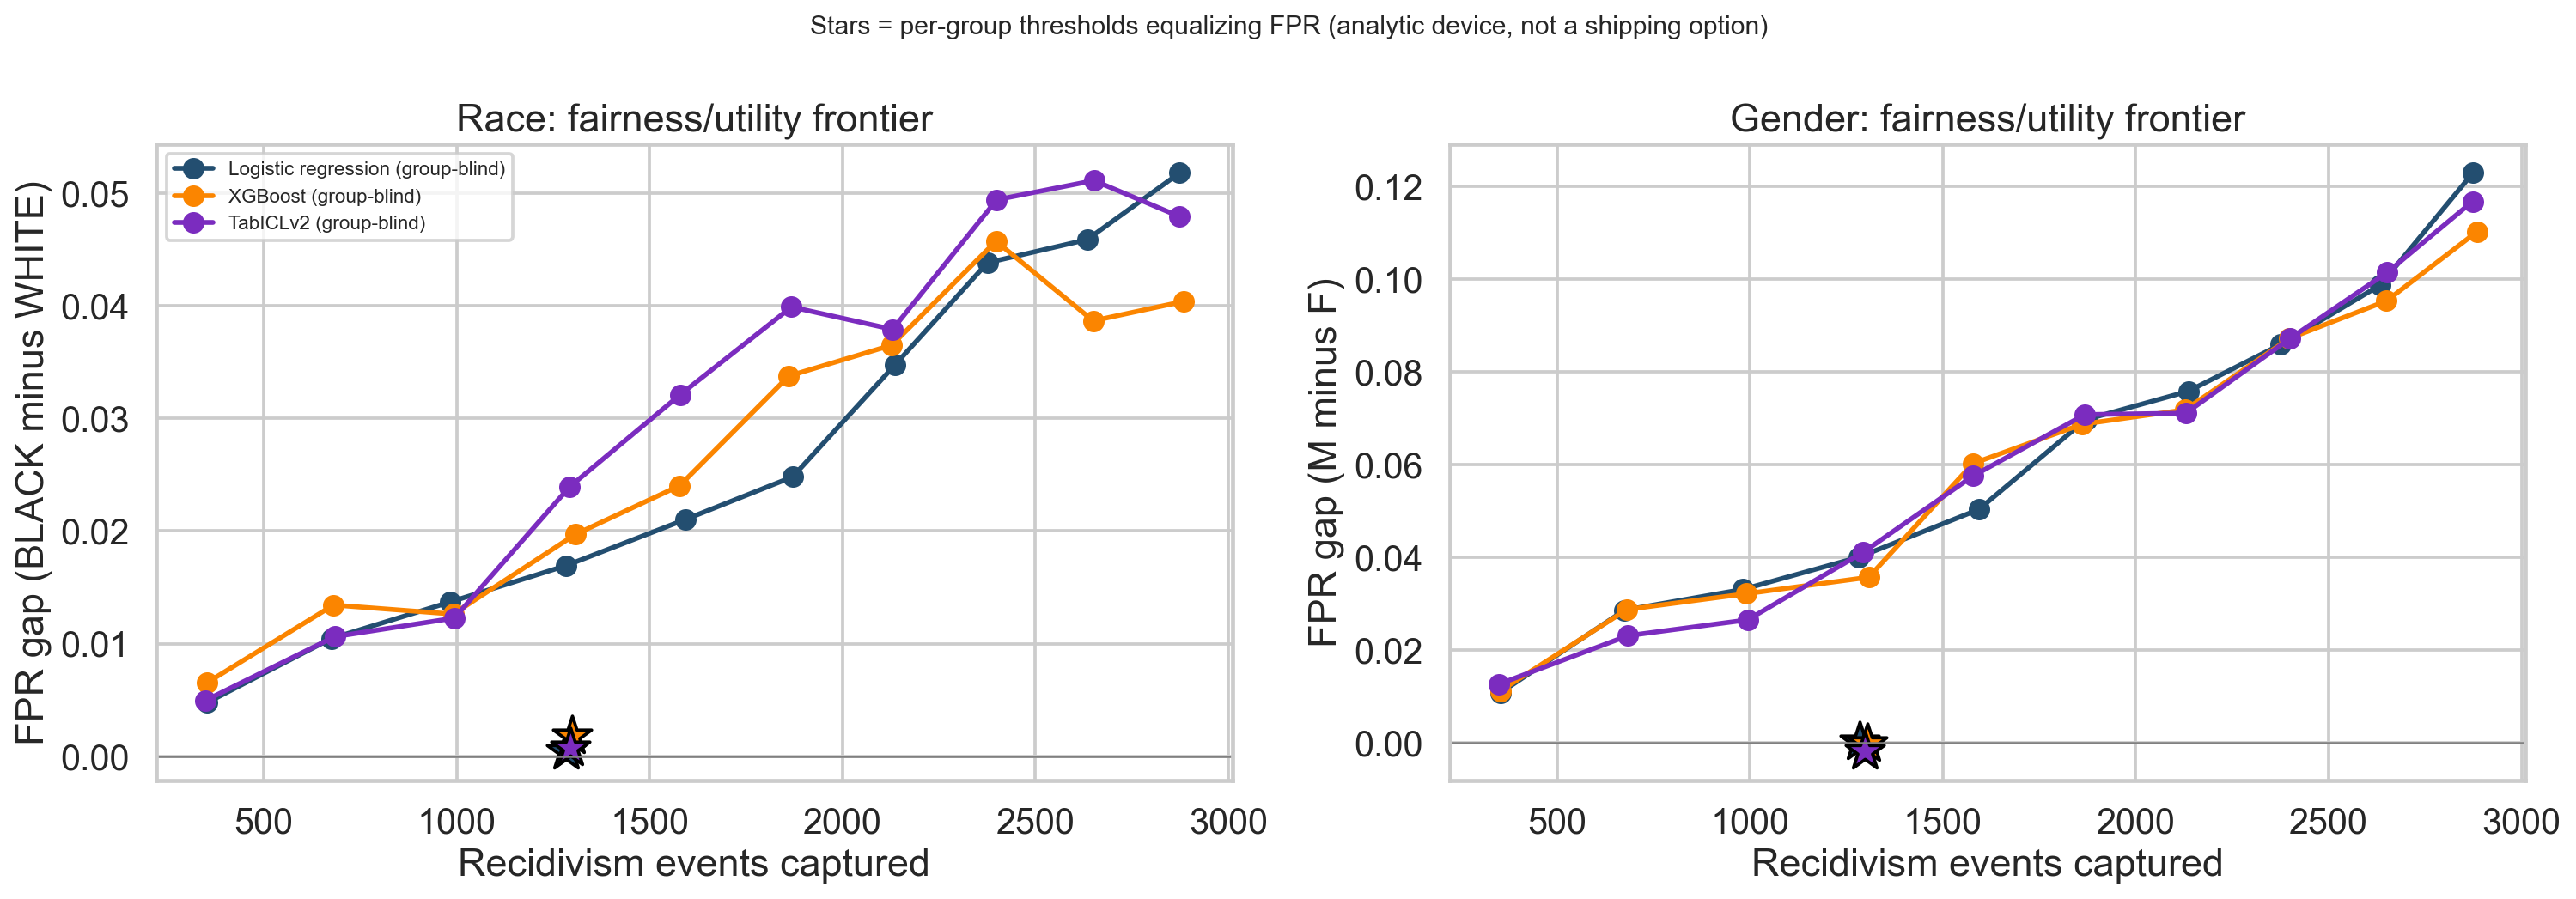

In [24]:
display(Image(filename=str(FIG / 'fairness_frontier.png'), width=1100))

Group thresholds drive both gaps to ~0 keeping nearly all captured events — but equalizing *gender* decalibrates women (base-rate gap 0.137), the trade-off the theorem forces.

### A/B test: does race add anything?

In [25]:
A('race_ab_test.csv').round(4)

,model,variant,roc_auc,twin_mean_abs_diff,twin_mean_diff_B_minus_W,twin_max_abs_diff,selection_gap_B_minus_W,fpr_gap_B_minus_W,tpr_gap_B_minus_W,mean_p_gap_B_minus_W
0,logistic,A_with_race,0.7294,0.0062,0.0062,0.0076,0.0257,0.0206,0.0233,0.0244
1,logistic,B_without_race,0.7295,0.0000,0.0000,0.0000,0.0178,0.0169,0.0123,0.0191
2,xgboost,A_with_race,0.7328,0.0083,0.0070,0.0482,0.0268,0.0243,0.0221,0.0256
3,xgboost,B_without_race,0.7326,0.0000,0.0000,0.0000,0.0178,0.0197,0.0098,0.0196
4,tabicl,A_with_race,0.7338,0.0093,0.0058,0.0451,0.0257,0.0199,0.0236,0.0268
5,tabicl,B_without_race,0.7328,0.0000,0.0000,0.0000,0.0268,0.0239,0.0225,0.0221


Adding race changes AUC by ≤0.0007 for every model but makes identical twins score differently (up to 4.8 pts for XGBoost). Removing race is free and guarantees identical twins — though TabICLv2's race gap rises slightly, evidence of proxy leakage (the limit of unawareness).

## 7. Trade-offs and recommendation

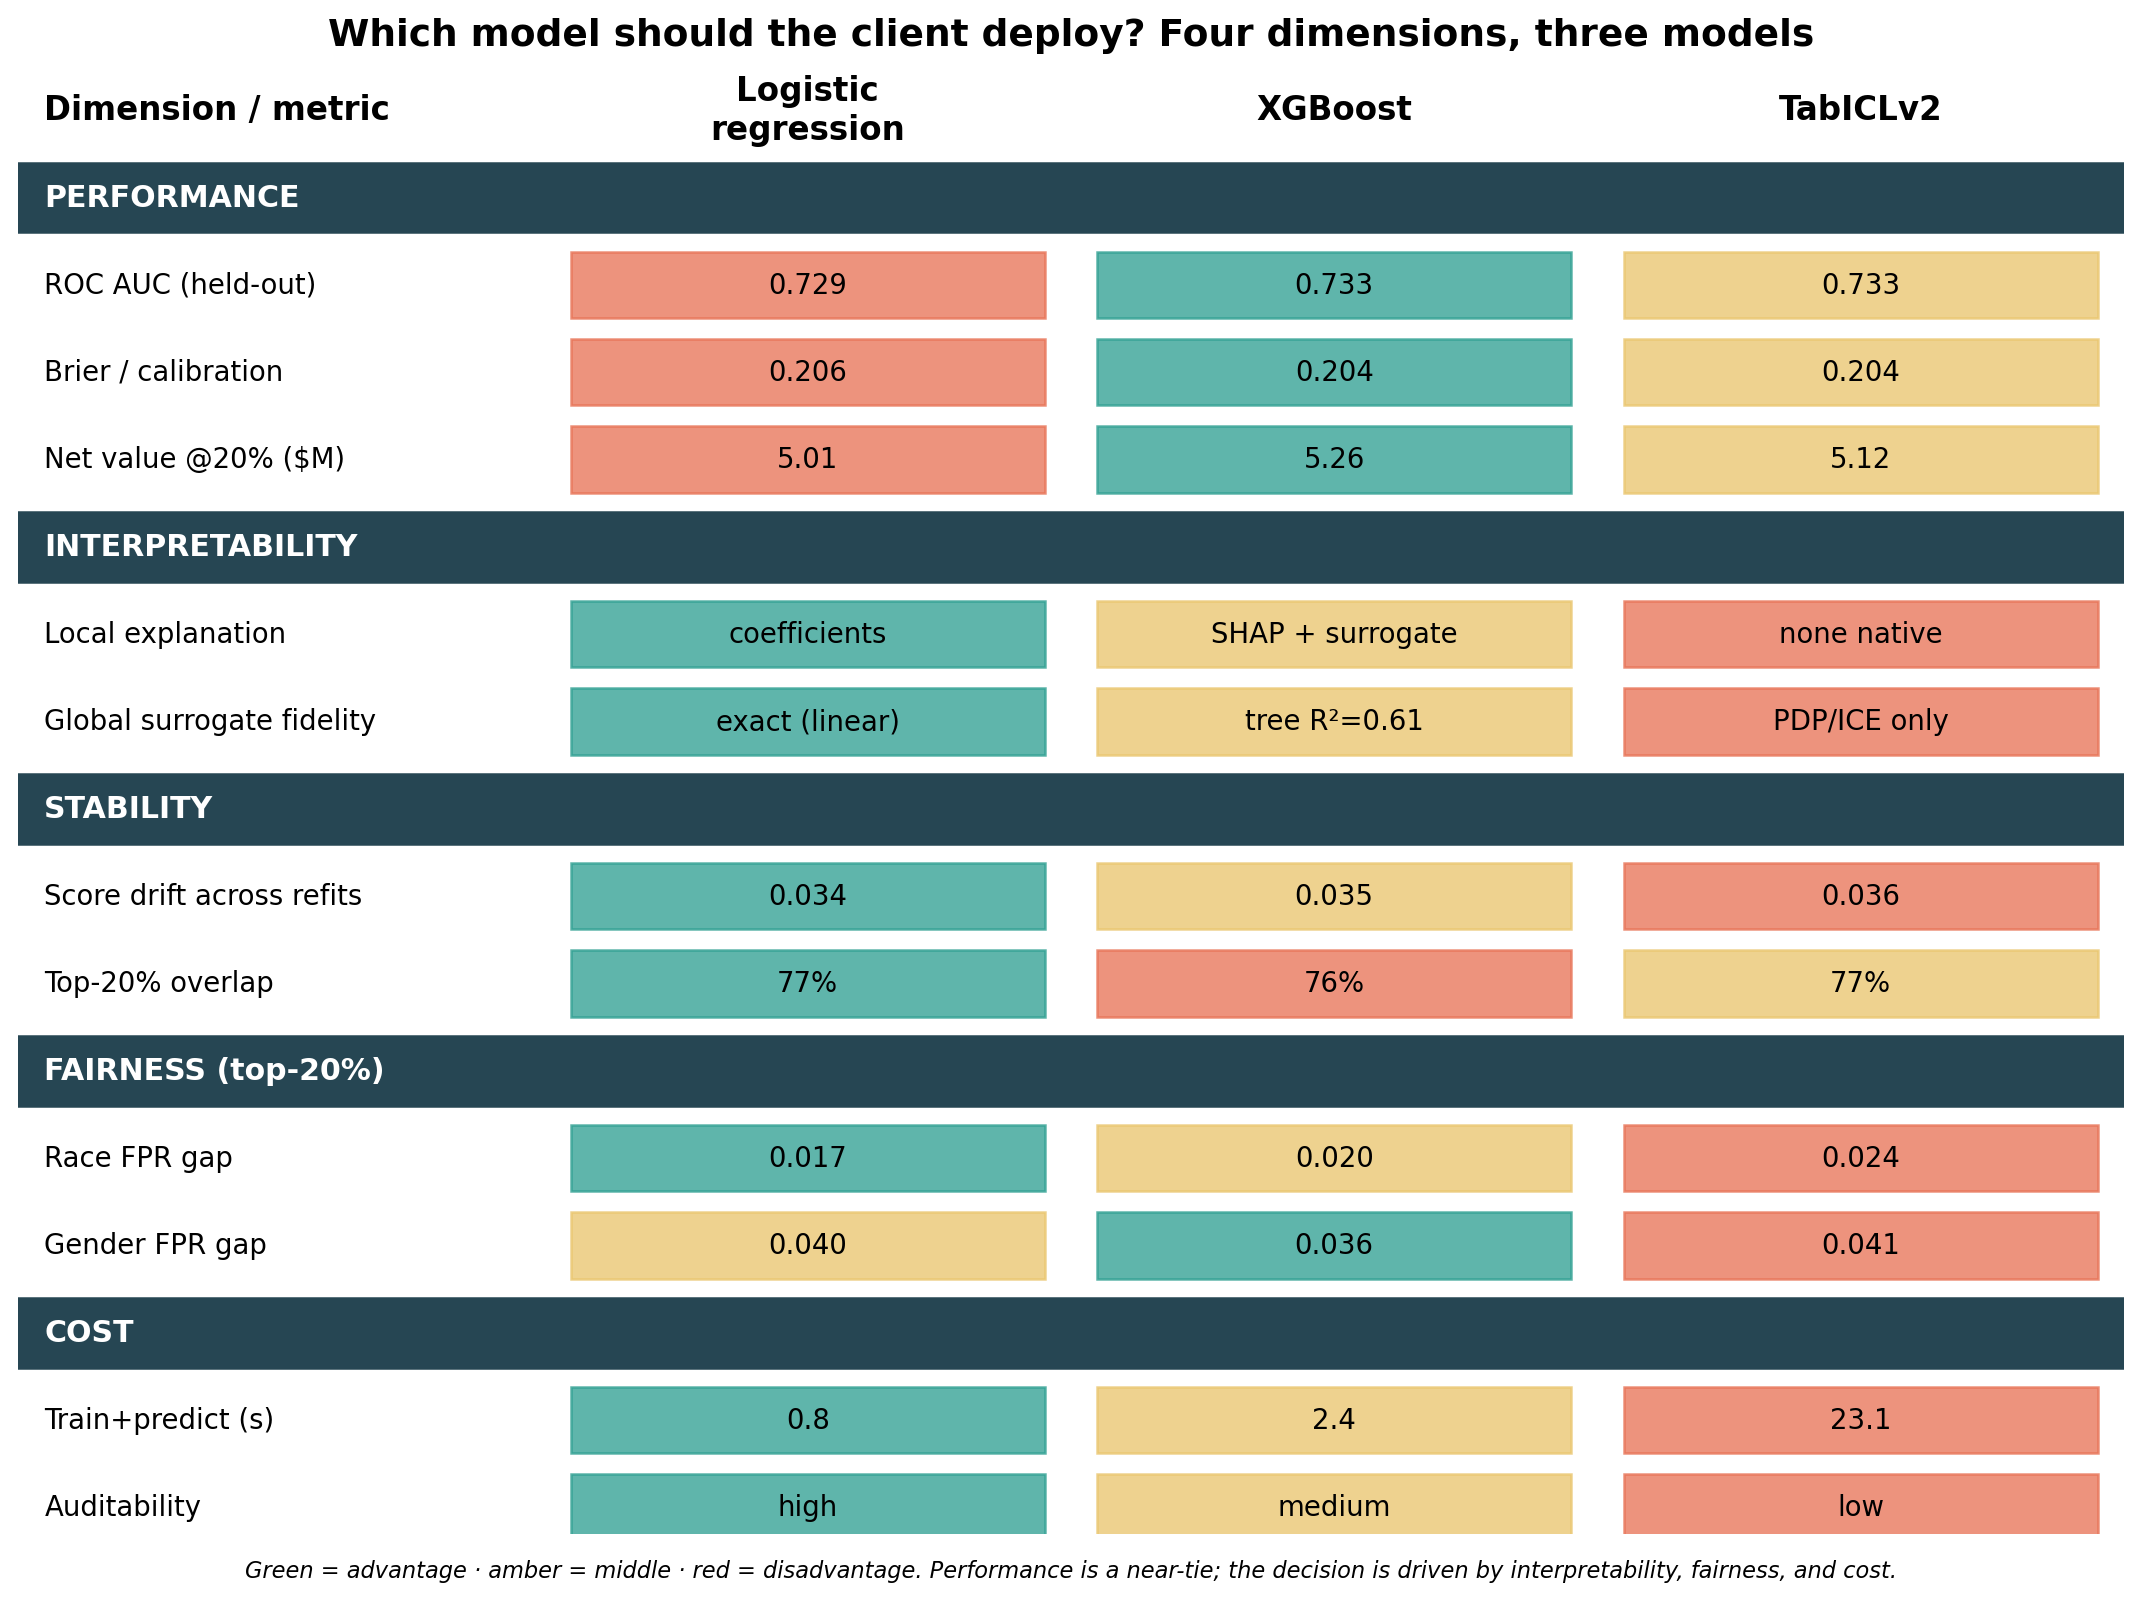

In [26]:
display(Image(filename=str(FIG / 'tradeoff_matrix.png'), width=1100))

Performance is a near-tie, so the decision turns on interpretability, fairness, stability and
cost. **Deploy XGBoost** (best calibration and net value, smallest gender gap, SHAP-explainable, ~10×
faster than the TFM), **logistic as transparent challenger**, **TabICLv2 only for very small
agencies** where its few-shot edge is real. Any deployment is benefit-only, with a prospective pilot,
an appeal route, quarterly subgroup audits at the deployed operating point, and stop rules.